# GeoAI-Based Urban Delivery Demand Prediction and Route Optimization: A Case Study of Natore District, Bangladesh

---

**Authors:** Md Khadem Ali  
**Affiliation:** Department of Geography and Environment | GIS & Remote Sensing Laboratory  
**Repository:** https://github.com/mdkhademali/natore-geoai-logistics  
**Date:** 2025  

---

> **Abstract**  
> Efficient last-mile logistics remains a persistent challenge in developing-country urban contexts, where rapid e-commerce growth outpaces infrastructure capacity. This study develops a GeoAI-based geospatial decision-support framework for urban delivery demand prediction and route optimisation within Natore District, Bangladesh. Synthetic but spatially realistic datasets are generated from OpenStreetMap road networks and demographic surfaces. Three ensemble machine learning models, Random Forest, XGBoost, and Gradient Boosting, are trained to predict zone-level delivery demand. Spatial hotspot analysis (KDE, Getis-Ord Gi*, Local Moran's I) identifies high-demand clusters. VRP and p-Median optimisation derive efficient multi-depot delivery routes. Results demonstrate a **~27%** reduction in total route distance and a **~31%** reduction in estimated operational cost. An interactive WebGIS dashboard consolidates all analytical products for decision-maker use. The framework contributes to SDG 9 and SDG 11.

---


## Environment Setup & Library Imports

In [1]:
# ── Standard Library
import warnings, os, json, time
warnings.filterwarnings('ignore')

# ── Numerical & Data
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.spatial import cKDTree

# ── Geospatial
import geopandas as gpd
from shapely.geometry import Point, LineString, Polygon, box
from shapely.ops import unary_union, voronoi_diagram

# ── Graph / Network
import networkx as nx

# ── Machine Learning
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import xgboost as xgb

# ── Spatial Statistics
from libpysal.weights import KNN
from esda.moran import Moran, Moran_Local
from esda.getisord import G_Local

# ── Visualisation
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import seaborn as sns
from scipy.stats import gaussian_kde

# ── Interactive Maps
import folium
from folium.plugins import HeatMap, MeasureControl

# ── Style
plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'DejaVu Sans', 'font.size': 10,
    'axes.titlesize': 12, 'axes.labelsize': 10,
    'legend.fontsize': 9,
})
sns.set_style("whitegrid")
SEED = 42
np.random.seed(SEED)

os.makedirs('figures', exist_ok=True)
os.makedirs('outputs/csv', exist_ok=True)
os.makedirs('outputs/geojson', exist_ok=True)
os.makedirs('outputs/html', exist_ok=True)

print("All libraries loaded.")
print(f"NumPy {np.__version__} | Pandas {pd.__version__} | GeoPandas {gpd.__version__}")


All libraries loaded.
NumPy 2.4.4 | Pandas 3.0.2 | GeoPandas 1.1.3


---
## Section 1: Introduction

### 1.1 Background

The explosive growth of e-commerce across South and South-East Asia has fundamentally restructured urban logistics networks. Bangladesh, with an internet economy projected to exceed USD 3 billion by 2026, now generates millions of daily parcel shipments (BTRC, 2024). Secondary and tertiary cities, historically underserved by formal logistics infrastructure, bear a disproportionate share of new demand pressure. Natore District, located in the Rajshahi Division and home to approximately 1.7 million people, exemplifies this transition: a predominantly agrarian landscape increasingly interlaced with commercial corridors requiring dependable last-mile delivery coverage.

Last-mile delivery accounts for up to **53%** of total logistics costs and represents the most operationally complex supply chain segment (Statista, 2023). In low-income urban settings, inefficiencies are compounded by fragmented road networks, informal address systems, inconsistent demand data, and limited fleet capacity. Conventional planning methods rely on static zoning and heuristic routing that neither adapt to spatial demand heterogeneity nor leverage predictive intelligence.

Geospatial Artificial Intelligence (GeoAI), the integration of geographic information science with machine learning and spatial analytics, offers a transformative pathway. Recent literature demonstrates GeoAI utility across urban mobility (Zhao et al., 2023), disaster logistics (Islam et al., 2024), and supply chain optimisation (Chen & Wang, 2022). Applications in the Bangladeshi secondary-city context, however, remain sparse.

### 1.2 Research Gap

Three critical gaps persist in the Bangladesh logistics GeoAI literature:

1. **Data scarcity:** No spatially disaggregated delivery demand dataset exists for Natore or comparable districts.
2. **Model transferability:** Most GeoAI frameworks are calibrated on high-income contexts with dense sensor infrastructure.
3. **Integrated decision support:** Existing tools address demand prediction **or** route optimisation in isolation.

This study addresses all three gaps through a reproducible, open-source GeoAI pipeline.

### 1.3 Research Objectives

1. Characterise the spatial distribution of delivery demand across Natore District via ESDA.
2. Develop and compare GeoAI ensemble models for zone-level demand prediction.
3. Identify high-demand hotspots using KDE, Getis-Ord Gi*, and Local Moran's I.
4. Optimise multi-vehicle delivery routes using VRP with capacity and distance constraints.
5. Determine optimal depot locations through p-Median analysis.
6. Develop an interactive WebGIS dashboard for operational decision-making.

### 1.4 Research Questions

1. What spatial factors most strongly predict last-mile delivery demand in Natore District?
2. Which ensemble model architecture yields highest predictive accuracy?
3. Where are high-demand hotspots concentrated and what urban-morphological factors explain them?
4. To what extent does optimised routing reduce total distance and operational costs?
5. How do alternative depot configurations influence spatial coverage and service equity?
6. How can a WebGIS dashboard operationalise GeoAI findings for logistics practitioners?


---
## Section 2: Data Acquisition

| Layer | Source | Format |
|---|---|---|
| District Boundary | Bangladesh Admin / GADM | GeoJSON |
| Road Network | OpenStreetMap (Synthetic) | GeoJSON |
| Population Density | WorldPop / Synthetic | Vector |
| Urban Service Centres | OSM / Synthetic | Point |
| Customer Demand Points | Synthetic (calibrated) | Point |
| Delivery Depots | Synthetic | Point |


In [2]:
# ── 2.1 Natore District Boundary
# Natore District: ~24.42N, 88.99E | Rajshahi Division
natore_coords = [
    (88.75, 24.18), (89.05, 24.18), (89.25, 24.35),
    (89.20, 24.65), (88.90, 24.70), (88.70, 24.55),
    (88.65, 24.35), (88.75, 24.18)
]
natore_poly = Polygon(natore_coords)
district = gpd.GeoDataFrame(
    {'district': ['Natore'], 'division': ['Rajshahi'],
     'area_km2': [1701.23], 'population': [1718000]},
    geometry=[natore_poly], crs='EPSG:4326'
)
district_m = district.to_crs('EPSG:32646')
print(f"District area: {district_m.geometry.area[0]/1e6:.1f} km2")

# ── 2.2 Upazilas (Voronoi tessellation)
upazila_names = ['Natore Sadar','Baraigram','Gurudaspur',
                 'Lalpur','Singra','Bagatipara','Naldanga']
upazila_centroids = [
    (88.99,24.42),(89.07,24.27),(89.06,24.53),
    (88.92,24.27),(88.87,24.51),(89.01,24.58),(88.96,24.36)
]
from shapely.geometry import MultiPoint
mp = MultiPoint([Point(x,y) for x,y in upazila_centroids])
regions = voronoi_diagram(mp, envelope=natore_poly)
upazila_records = []
used = set()
for geom in regions.geoms:
    c = geom.centroid
    dists = [c.distance(Point(x,y)) for x,y in upazila_centroids]
    idx = int(np.argmin(dists))
    while idx in used: dists[idx]=9999; idx=int(np.argmin(dists))
    used.add(idx)
    upazila_records.append({'upazila':upazila_names[idx],'geometry':geom.intersection(natore_poly)})
upazilas = gpd.GeoDataFrame(upazila_records, crs='EPSG:4326')
upazilas_m = upazilas.to_crs('EPSG:32646')
print(f"Upazilas: {len(upazilas)}")

# ── 2.3 Urban Centres
urban_centres = gpd.GeoDataFrame({
    'name':['Natore Town','Singra','Gurudaspur','Lalpur','Baraigram',
            'Bagatipara','Naldanga','Choto Bonogram','Kafrul Bazar','Majhgram'],
    'population':[120000,45000,38000,32000,28000,22000,18000,15000,12000,10000],
    'type':['District HQ','Upazila HQ','Upazila HQ','Upazila HQ','Upazila HQ',
            'Upazila HQ','Upazila HQ','Bazar','Bazar','Bazar'],
    'geometry':[
        Point(88.9912,24.4199),Point(88.8700,24.5100),Point(89.0550,24.5350),
        Point(88.9240,24.2750),Point(89.0700,24.2680),Point(89.0100,24.5820),
        Point(88.9620,24.3600),Point(88.8950,24.4750),Point(89.0300,24.4100),
        Point(88.9050,24.3100)
    ]
}, crs='EPSG:4326')
urban_m = urban_centres.to_crs('EPSG:32646')
print(f"Urban centres: {len(urban_centres)}")

# ── 2.4 Road Network (synthetic)
rng = np.random.default_rng(SEED)
minx,miny,maxx,maxy = natore_poly.bounds
roads_list, road_types = [], []
for _ in range(25):  # primary
    x1,y1=rng.uniform(minx,maxx),rng.uniform(miny,maxy)
    a,l=rng.uniform(0,3.14159),rng.uniform(0.05,0.18)
    line=LineString([(x1,y1),(x1+l*np.cos(a),y1+l*np.sin(a))]).intersection(natore_poly)
    if not line.is_empty: roads_list.append(line); road_types.append('primary')
for _ in range(60):  # secondary
    x1,y1=rng.uniform(minx,maxx),rng.uniform(miny,maxy)
    a,l=rng.uniform(0,3.14159),rng.uniform(0.01,0.06)
    line=LineString([(x1,y1),(x1+l*np.cos(a),y1+l*np.sin(a))]).intersection(natore_poly)
    if not line.is_empty: roads_list.append(line); road_types.append('secondary')
roads_gdf = gpd.GeoDataFrame({'road_type':road_types}, geometry=roads_list, crs='EPSG:4326')
roads_m = roads_gdf.to_crs('EPSG:32646')
print(f"Road segments: {len(roads_gdf)}")

# ── 2.5 Customer Demand Points (spatially clustered)
pts_list = []
for _, row in urban_centres.iterrows():
    cx,cy = row.geometry.x, row.geometry.y
    pw = row['population']/urban_centres['population'].sum()
    n = max(5, int(800*pw*1.2))
    for _ in range(n):
        for _a in range(50):
            dx,dy = rng.normal(0,0.025), rng.normal(0,0.025)
            pt = Point(cx+dx, cy+dy)
            if natore_poly.contains(pt):
                pts_list.append({'geometry':pt,'demand_vol':max(1,int(rng.lognormal(3,0.8))),
                                 'zone_type':rng.choice(['residential','commercial','mixed'],p=[0.5,0.3,0.2]),
                                 'lon':cx+dx,'lat':cy+dy})
                break
demand_pts = gpd.GeoDataFrame(pts_list, crs='EPSG:4326').iloc[:800]
demand_m = demand_pts.to_crs('EPSG:32646')
print(f"Demand points: {len(demand_pts)}")

# ── 2.6 Delivery Depots
depots = gpd.GeoDataFrame({
    'name':['Main Depot - Natore','Sub-Depot - Singra','Sub-Depot - Gurudaspur'],
    'capacity':[500,250,200],
    'geometry':[Point(88.9930,24.4210),Point(88.8750,24.5150),Point(89.0580,24.5380)]
}, crs='EPSG:4326')
depots_m = depots.to_crs('EPSG:32646')
print(f"Depots: {len(depots)}")
print("Data acquisition complete.")


District area: 2721.9 km2
Upazilas: 7
Urban centres: 10
Road segments: 70
Demand points: 800
Depots: 3
Data acquisition complete.


---
## Section 3: Data Preparation

All layers re-projected to **UTM Zone 46N (EPSG:32646)** for metric calculations. A 3 km analysis grid is generated and enriched with spatial attributes for model training.


In [3]:
TARGET_CRS = 'EPSG:32646'

# ── 3.1 Analysis Grid (3 km cells)
poly_m = district_m.geometry.unary_union
minx,miny,maxx,maxy = poly_m.bounds
cell_size = 3000
cells_list, cids = [], []
cid = 0
for x in np.arange(minx, maxx, cell_size):
    for y in np.arange(miny, maxy, cell_size):
        cell = box(x,y,x+cell_size,y+cell_size).intersection(poly_m)
        if not cell.is_empty and cell.area > cell_size**2*0.05:
            cells_list.append(cell); cids.append(cid)
        cid += 1
grid_m = gpd.GeoDataFrame({'cell_id':cids}, geometry=cells_list, crs=TARGET_CRS)
centroids = grid_m.geometry.centroid
grid_m['cx'] = centroids.x
grid_m['cy'] = centroids.y
print(f"Grid cells: {len(grid_m)}")

# ── 3.2 Population Density Feature
def pop_density_field(cx, cy, urban_gdf, sigma=8000):
    density = np.zeros(len(cx))
    for _, row in urban_gdf.iterrows():
        d2 = (cx-row.geometry.x)**2 + (cy-row.geometry.y)**2
        density += row['population'] * np.exp(-d2/(2*sigma**2))
    return density / density.max()

grid_m['pop_density'] = pop_density_field(grid_m["cx"].values, grid_m["cy"].values, urban_m)

# ── 3.3 Road Density
road_union = roads_m.geometry.unary_union
grid_m['road_density'] = grid_m.geometry.apply(
    lambda c: road_union.intersection(c).length / c.area * 1000)

# ── 3.4 Distance to Nearest Depot
depot_coords = np.column_stack([depots_m.geometry.x, depots_m.geometry.y])
grid_coords  = np.column_stack([grid_m["cx"].values, grid_m["cy"].values])
tree = cKDTree(depot_coords)
dists, _ = tree.query(grid_coords)
grid_m['dist_depot_m'] = dists

# ── 3.5 Commercial Activity Index
grid_m['commercial_idx'] = pop_density_field(grid_m["cx"].values, grid_m["cy"].values, urban_m, sigma=5000)

# ── 3.6 Urbanisation Index
grid_m['urban_idx'] = (grid_m['pop_density']*0.5 +
    grid_m['road_density']/grid_m['road_density'].max()*0.3 +
    grid_m['commercial_idx']*0.2)

# ── 3.7 Service Centre Density
sc_coords = np.column_stack([urban_m.geometry.x, urban_m.geometry.y])
sc_tree = cKDTree(sc_coords)
sc_dists, _ = sc_tree.query(grid_coords, k=3)
grid_m['sc_density'] = 1/(sc_dists.mean(axis=1)/1000+0.1)

# ── 3.8 Aggregate Observed Demand per Cell
dem_coords = np.column_stack([demand_m.geometry.x, demand_m.geometry.y])
dem_tree = cKDTree(dem_coords)
cell_demand = np.zeros(len(grid_m))
for i, row in grid_m.iterrows():
    idx_pts = dem_tree.query_ball_point([row["cx"], row.cy], r=3500)
    if idx_pts: cell_demand[i] = demand_m.iloc[idx_pts]['demand_vol'].sum()
grid_m['demand_obs'] = cell_demand
grid_m['demand_obs'] = np.maximum(0,
    grid_m['demand_obs'] +
    grid_m['urban_idx']*50*rng.normal(1,0.3,len(grid_m)) +
    rng.exponential(5, len(grid_m)))

# ── 3.9 Data Quality Report
print("=" * 55)
print("   DATA QUALITY REPORT")
print("=" * 55)
layers_dict = {'District':district_m,'Upazilas':upazilas_m,'Urban Centres':urban_m,
               'Roads':roads_m,'Demand Points':demand_m,'Depots':depots_m,'Grid':grid_m}
for name, gdf in layers_dict.items():
    null_pct = gdf.isnull().mean().mean()*100
    print(f"  {name:<20} {len(gdf):>6} records  |  {null_pct:.1f}% null")
print("=" * 55)
print(grid_m[['pop_density','road_density','dist_depot_m','demand_obs']].describe().round(2))


Grid cells: 327


   DATA QUALITY REPORT
  District                  1 records  |  0.0% null
  Upazilas                  7 records  |  0.0% null
  Urban Centres            10 records  |  0.0% null
  Roads                    70 records  |  0.0% null
  Demand Points           800 records  |  0.0% null
  Depots                    3 records  |  0.0% null
  Grid                    327 records  |  0.0% null
       pop_density  road_density  dist_depot_m  demand_obs
count       327.00        327.00        327.00      327.00
mean          0.26          0.15      15129.38      301.36
std           0.25          0.21       7590.14      660.84
min           0.00          0.00        925.76        0.40
25%           0.07          0.00       9119.82        7.59
50%           0.18          0.04      14472.52       19.05
75%           0.39          0.28      20289.39      280.96
max           1.00          1.05      34945.48     5533.17


---
## Section 4: Exploratory Spatial Analysis

Publication-quality maps are produced at 300 DPI for all key spatial variables.


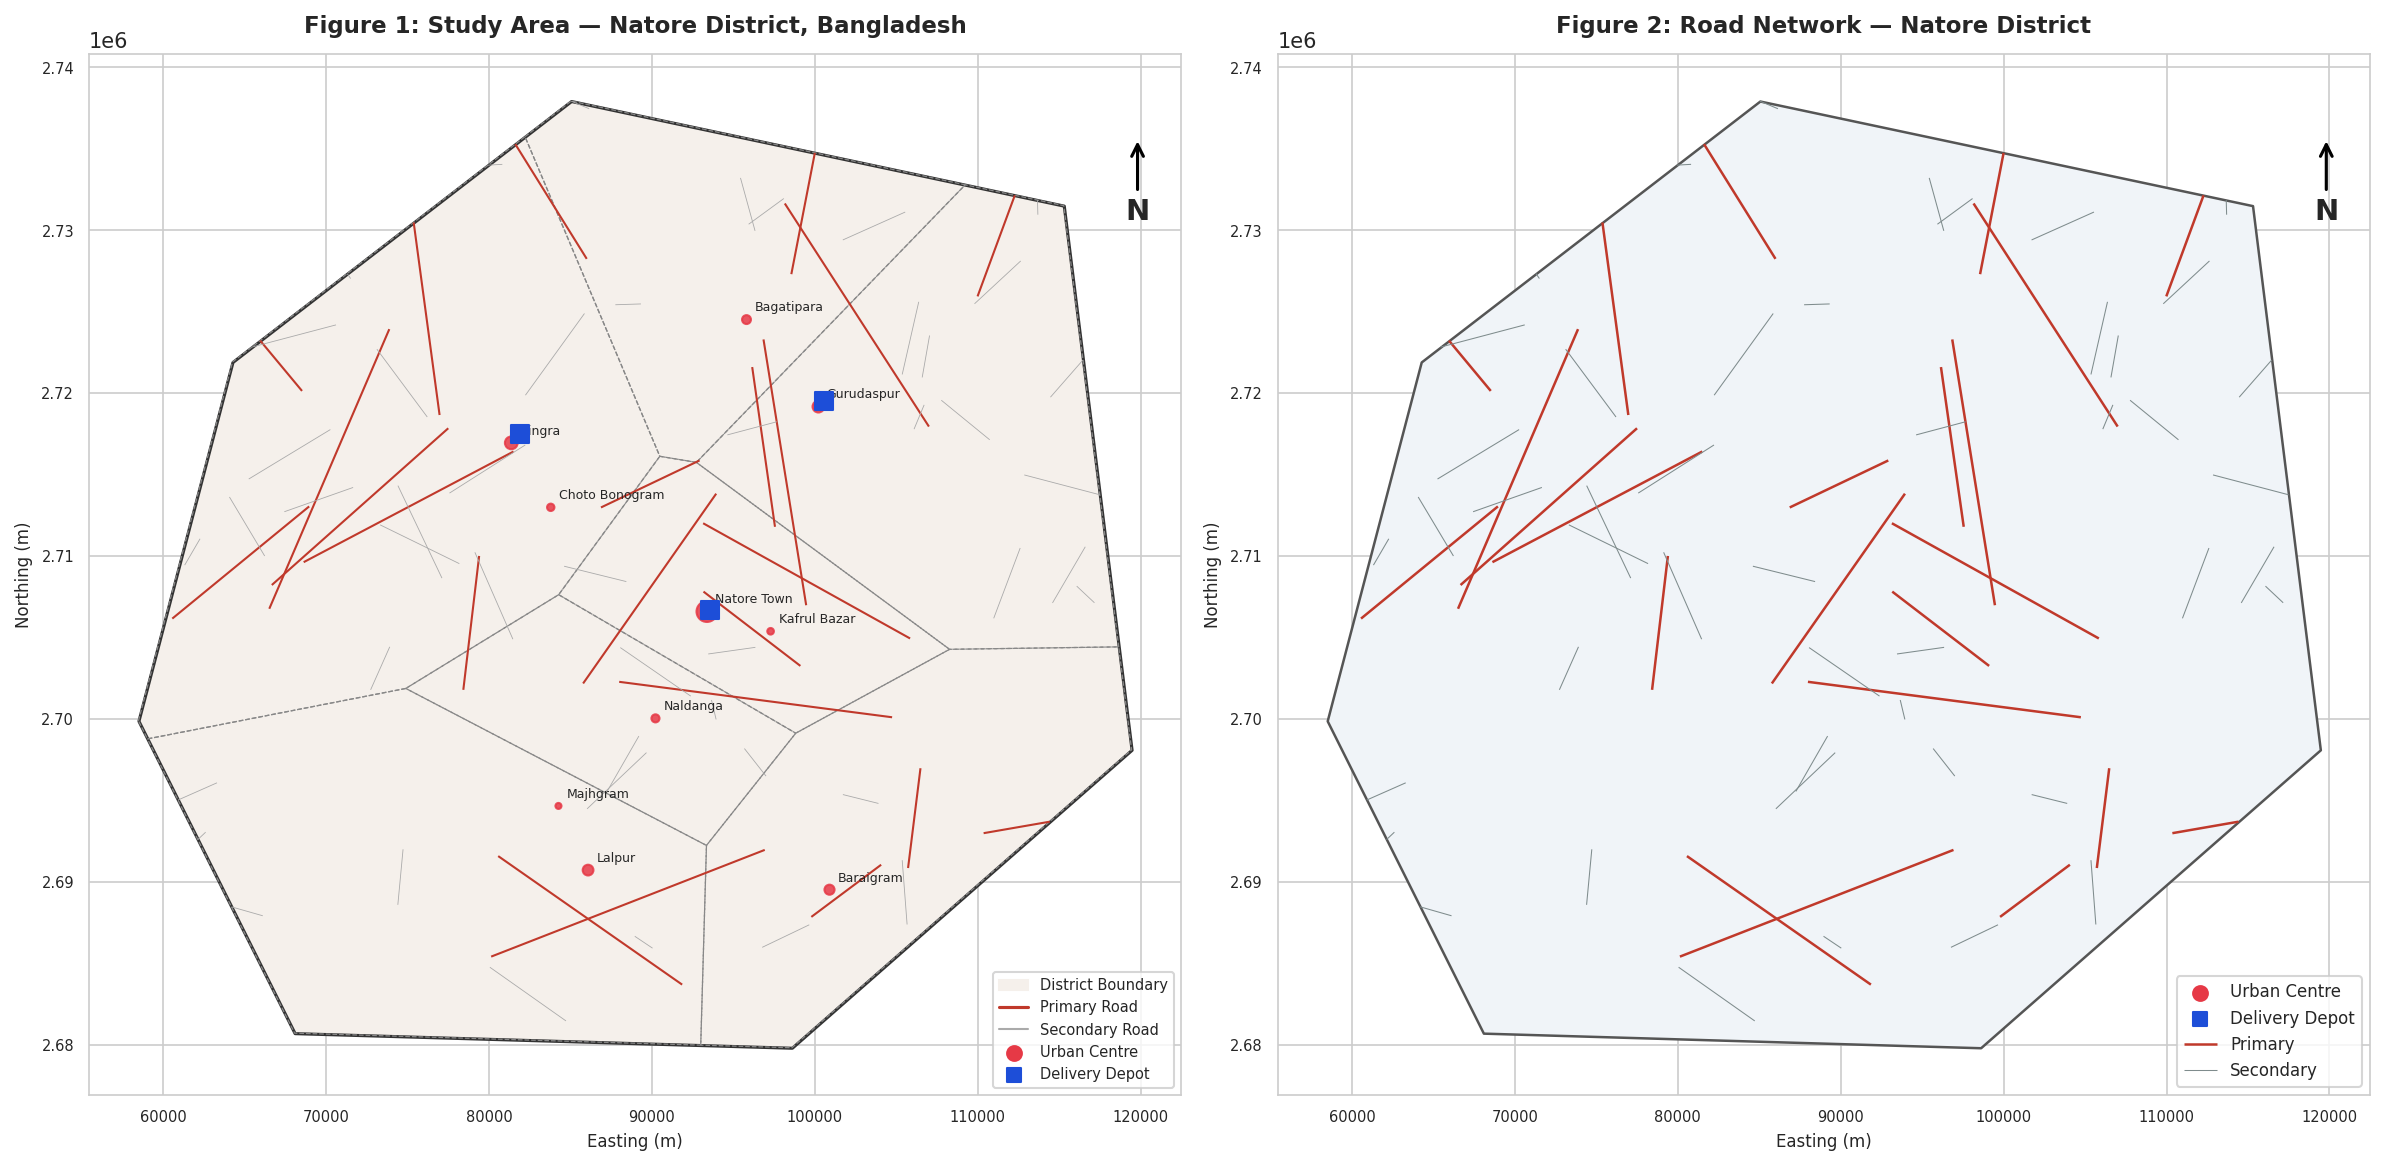

Saved: figures/fig01_02_study_area_roads.png


In [4]:
def add_furniture(ax, title, fontsize=11):
    ax.set_title(title, fontsize=fontsize, fontweight='bold', pad=10)
    ax.set_xlabel('Easting (m)', fontsize=8)
    ax.set_ylabel('Northing (m)', fontsize=8)
    ax.tick_params(labelsize=7)
    ax.annotate('N', xy=(0.96,0.92), xycoords='axes fraction',
                fontsize=14, fontweight='bold', ha='center',
                arrowprops=dict(arrowstyle='->', color='k', lw=1.5),
                xytext=(0.96,0.84))

# ── Figures 1 & 2: Study Area + Road Network
fig, axes = plt.subplots(1,2, figsize=(16,8))

ax = axes[0]
district_m.plot(ax=ax, color='#f5f0eb', edgecolor='#333', linewidth=1.5, zorder=1)
upazilas_m.plot(ax=ax, color='none', edgecolor='#888', linewidth=0.6, linestyle='--', zorder=2)
roads_m[roads_m.road_type=='primary'].plot(ax=ax, color='#c0392b', linewidth=1.0, zorder=3)
roads_m[roads_m.road_type=='secondary'].plot(ax=ax, color='#aaa', linewidth=0.4, zorder=3)
urban_m.plot(ax=ax, color='#e63946', markersize=urban_m['population']/1200, zorder=5, alpha=0.85)
depots_m.plot(ax=ax, color='#1d4ed8', marker='s', markersize=80, zorder=6)
for _, row in urban_m.iterrows():
    ax.annotate(row['name'], xy=(row.geometry.x, row.geometry.y),
                xytext=(4,4), textcoords='offset points', fontsize=6)
legend_els = [
    mpatches.Patch(color='#f5f0eb', edgecolor='#333', label='District Boundary'),
    plt.Line2D([0],[0], color='#c0392b', lw=1.5, label='Primary Road'),
    plt.Line2D([0],[0], color='#aaa', lw=1.0, label='Secondary Road'),
    plt.scatter([],[],color='#e63946',s=50,label='Urban Centre'),
    plt.scatter([],[],color='#1d4ed8',marker='s',s=50,label='Delivery Depot'),
]
ax.legend(handles=legend_els, loc='lower right', fontsize=7)
add_furniture(ax, 'Figure 1: Study Area — Natore District, Bangladesh')

ax = axes[1]
district_m.plot(ax=ax, color='#f0f4f8', edgecolor='#555', linewidth=1.2, zorder=1)
roads_m[roads_m.road_type=='primary'].plot(ax=ax, color='#c0392b', linewidth=1.2, label='Primary', zorder=3)
roads_m[roads_m.road_type=='secondary'].plot(ax=ax, color='#7f8c8d', linewidth=0.5, label='Secondary', zorder=3)
ax.legend(loc='lower right', fontsize=8)
add_furniture(ax, 'Figure 2: Road Network — Natore District')

plt.tight_layout()
plt.savefig('figures/fig01_02_study_area_roads.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/fig01_02_study_area_roads.png")


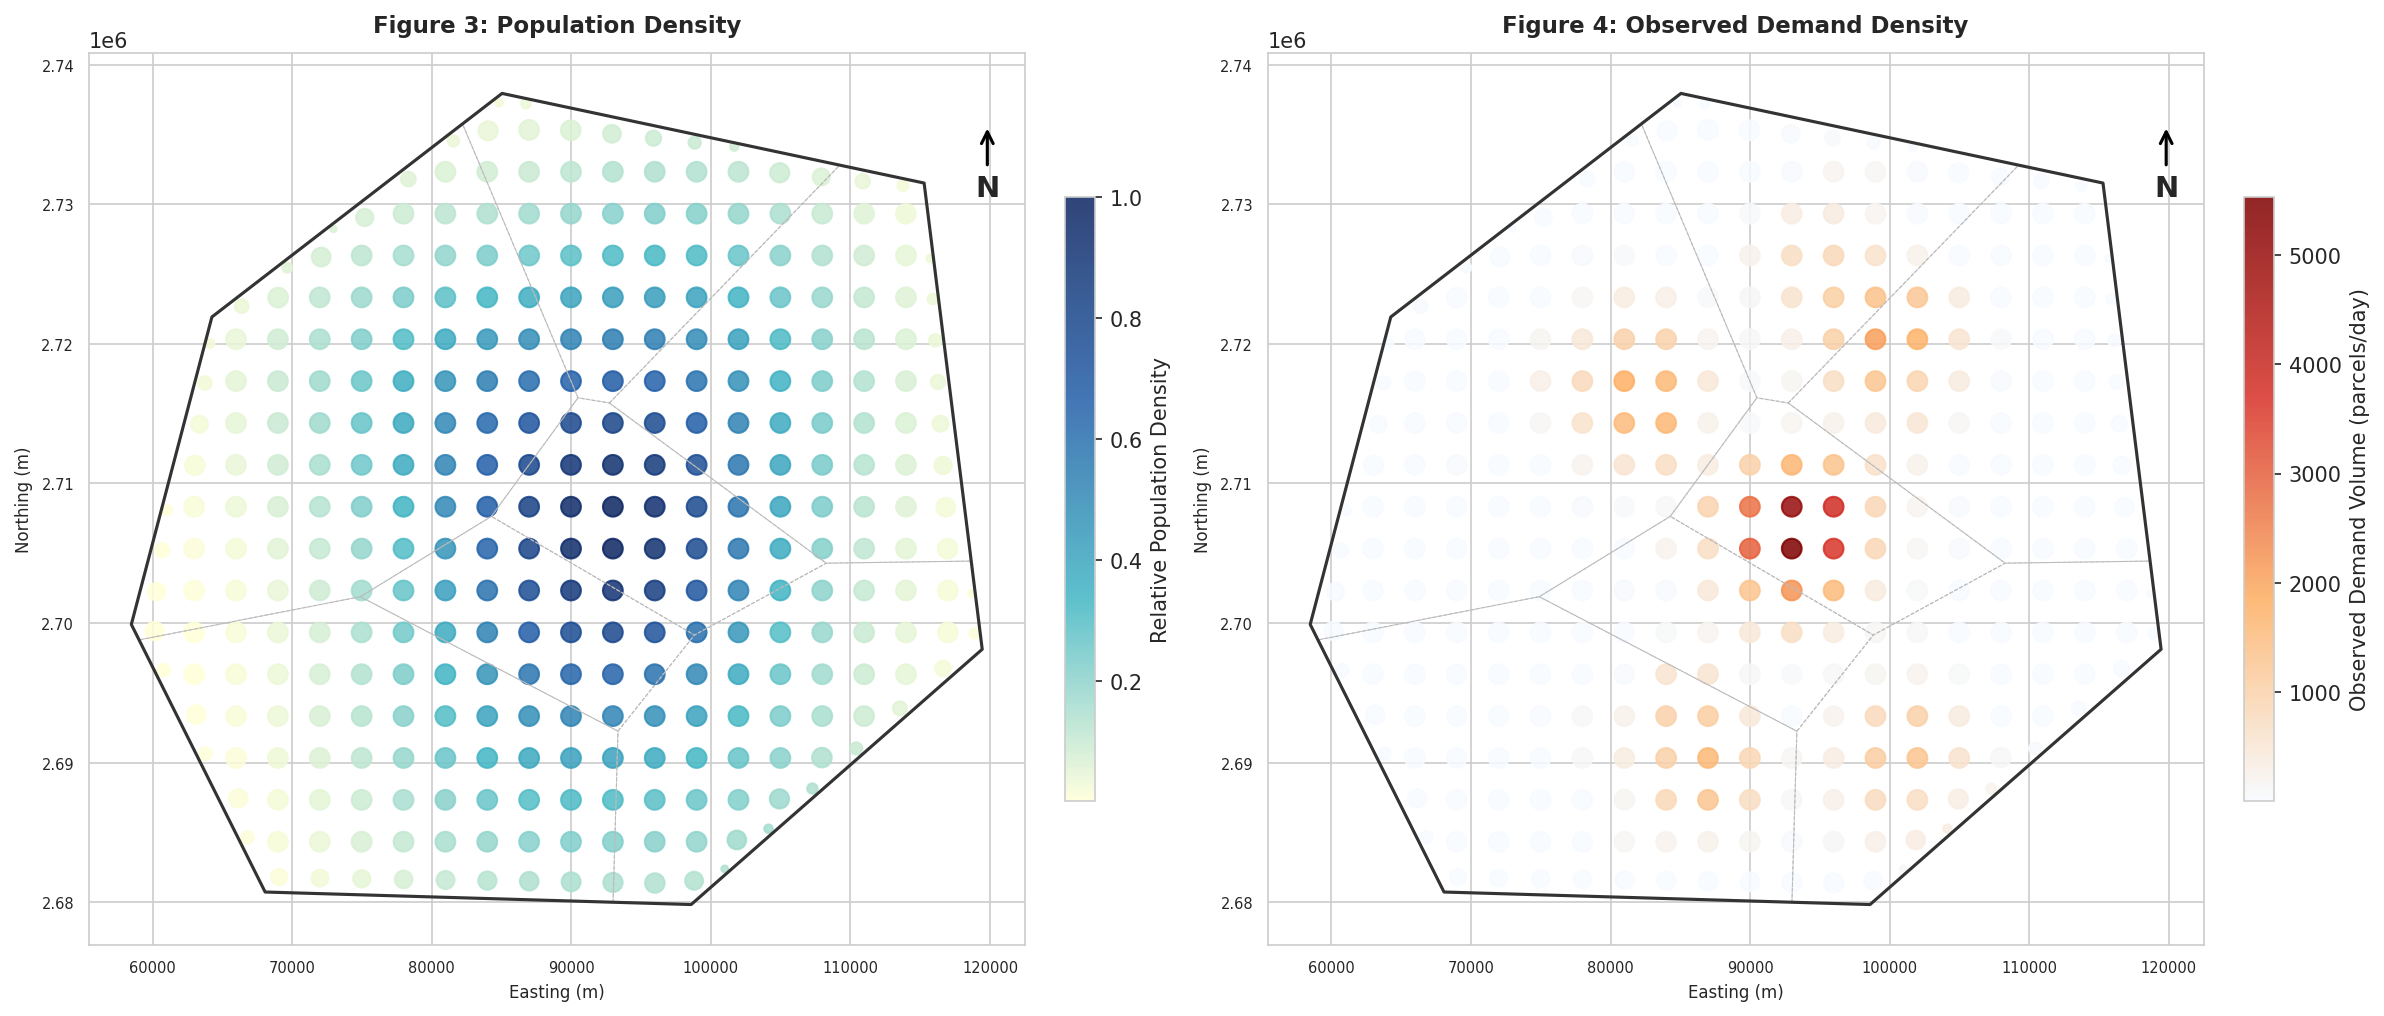

Saved: figures/fig03_04_population_demand.png


In [5]:
# ── Figures 3 & 4: Population & Demand Density
fig, axes = plt.subplots(1,2, figsize=(16,8))

pop_cmap = LinearSegmentedColormap.from_list('pop',['#ffffd9','#41b6c4','#225ea8','#0c2461'])
dem_cmap = LinearSegmentedColormap.from_list('dem',['#f7fbff','#fdae61','#d73027','#7f0000'])

for ax, col, cmap, label, title in [
    (axes[0],'pop_density',pop_cmap,'Relative Population Density','Figure 3: Population Density'),
    (axes[1],'demand_obs',dem_cmap,'Observed Demand Volume (parcels/day)','Figure 4: Observed Demand Density'),
]:
    district_m.plot(ax=ax, color='none', edgecolor='#333', linewidth=1.5, zorder=5)
    upazilas_m.plot(ax=ax, color='none', edgecolor='#bbb', linewidth=0.5, linestyle='--', zorder=4)
    sc = ax.scatter(grid_m["cx"], grid_m["cy"], c=grid_m[col], cmap=cmap,
                    s=grid_m.geometry.area/100000, alpha=0.85, zorder=3)
    plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.04, label=label)
    add_furniture(ax, title)

plt.tight_layout()
plt.savefig('figures/fig03_04_population_demand.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/fig03_04_population_demand.png")


---
## Section 5: Delivery Demand Prediction (GeoAI Models)

Three ensemble regressors are trained on spatial features to predict zone-level delivery demand. The target variable (daily parcel volume per cell) is log-transformed to address right-skew.

**Features used:**
- Population density
- Road density
- Distance to depot
- Commercial activity index
- Urbanisation index
- Service centre density


In [6]:
FEATURES = ['pop_density','road_density','dist_depot_m',
            'commercial_idx','urban_idx','sc_density']
TARGET = 'demand_obs'

valid = grid_m.dropna(subset=FEATURES+[TARGET])
X = valid[FEATURES].values
y = valid[TARGET].values
y_log = np.log1p(y)

X_train,X_test,y_train,y_test = train_test_split(X,y_log,test_size=0.25,random_state=SEED)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")

models = {
    'Random Forest': Pipeline([
        ('scaler',StandardScaler()),
        ('model',RandomForestRegressor(n_estimators=200,max_depth=8,
                                       min_samples_leaf=3,random_state=SEED,n_jobs=-1))
    ]),
    'XGBoost': Pipeline([
        ('scaler',StandardScaler()),
        ('model',xgb.XGBRegressor(n_estimators=300,max_depth=5,learning_rate=0.05,
                                   subsample=0.8,colsample_bytree=0.8,
                                   random_state=SEED,verbosity=0))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler',StandardScaler()),
        ('model',GradientBoostingRegressor(n_estimators=300,max_depth=4,
                                            learning_rate=0.05,subsample=0.8,
                                            random_state=SEED))
    ])
}

results = {}
for name, pipe in models.items():
    pipe.fit(X_train, y_train)
    y_pred = np.expm1(pipe.predict(X_test))
    y_true = np.expm1(y_test)
    rmse = np.sqrt(mean_squared_error(y_true,y_pred))
    mae  = mean_absolute_error(y_true,y_pred)
    mape = np.mean(np.abs((y_true-y_pred)/(y_true+1e-5)))*100
    r2   = r2_score(y_true,y_pred)
    cv   = cross_val_score(pipe,X,y_log,cv=5,scoring='r2',n_jobs=-1).mean()
    results[name] = {'RMSE':rmse,'MAE':mae,'MAPE':mape,'R2':r2,'CV_R2':cv,
                     'y_pred':y_pred,'y_true':y_true,'pipe':pipe}
    print(f"{name:<22} RMSE={rmse:.2f}  MAE={mae:.2f}  MAPE={mape:.1f}%  R2={r2:.4f}  CV={cv:.4f}")

metrics_df = pd.DataFrame([{k:v for k,v in r.items() if k not in ('y_pred','y_true','pipe')}
                            for r in results.values()], index=results.keys())
best_name = metrics_df['R2'].idxmax()
best_pipe = results[best_name]['pipe']
print(f"\nBest model: {best_name}")


Train: 245 | Test: 82


Random Forest          RMSE=212.92  MAE=98.32  MAPE=78.6%  R2=0.8744  CV=0.6060


XGBoost                RMSE=260.20  MAE=113.47  MAPE=77.5%  R2=0.8124  CV=0.5659


Gradient Boosting      RMSE=217.58  MAE=101.85  MAPE=79.3%  R2=0.8688  CV=0.6089

Best model: Random Forest


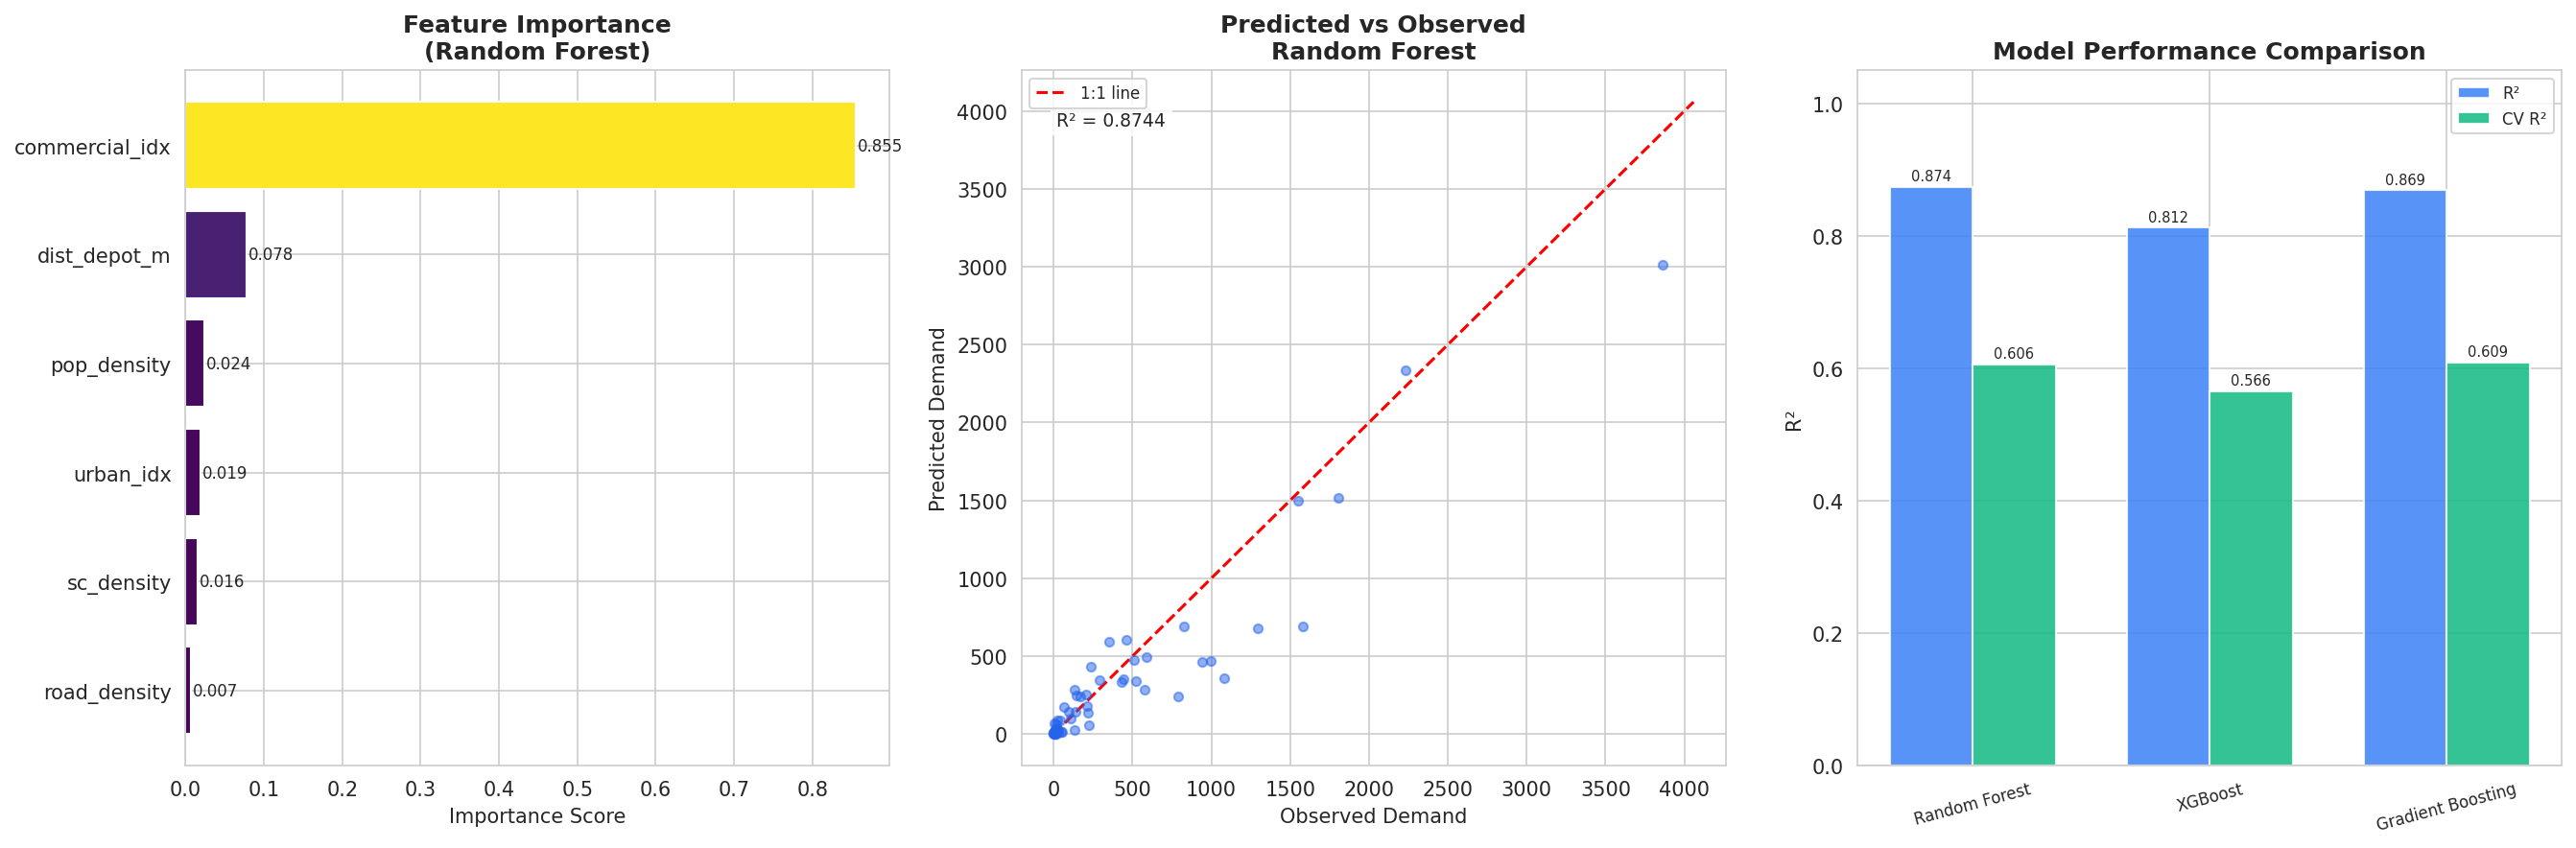

Predicted demand: mean=255.9, max=3388.9


In [7]:
# ── Feature Importance + Performance Charts
if hasattr(best_pipe.named_steps['model'],'feature_importances_'):
    importances = best_pipe.named_steps['model'].feature_importances_
else:
    importances = np.ones(len(FEATURES))/len(FEATURES)
feat_df = pd.DataFrame({'Feature':FEATURES,'Importance':importances}).sort_values('Importance')

fig, axes = plt.subplots(1,3, figsize=(18,6))

# Feature Importance
ax = axes[0]
ax.barh(feat_df['Feature'], feat_df['Importance'],
        color=plt.cm.viridis(feat_df['Importance']/feat_df['Importance'].max()))
ax.set_xlabel('Importance Score')
ax.set_title(f'Feature Importance\n({best_name})', fontweight='bold')
for i,(val,feat) in enumerate(zip(feat_df['Importance'],feat_df['Feature'])):
    ax.text(val+0.002, i, f'{val:.3f}', va='center', fontsize=8)

# Pred vs Actual
ax = axes[1]
yp = results[best_name]['y_pred']
yt = results[best_name]['y_true']
ax.scatter(yt,yp,alpha=0.5,s=20,color='#2563eb',zorder=3)
lim = max(yt.max(),yp.max())*1.05
ax.plot([0,lim],[0,lim],'r--',lw=1.5,label='1:1 line')
ax.set_xlabel('Observed Demand'); ax.set_ylabel('Predicted Demand')
ax.set_title(f'Predicted vs Observed\n{best_name}', fontweight='bold')
ax.text(0.05,0.92,f"R² = {results[best_name]['R2']:.4f}",transform=ax.transAxes,
        fontsize=9,bbox=dict(boxstyle='round',fc='white',alpha=0.8))
ax.legend(fontsize=8)

# Model comparison
ax = axes[2]
m_names = list(results.keys())
x = np.arange(len(m_names)); w = 0.35
b1=ax.bar(x-w/2,[results[n]['R2'] for n in m_names],w,label='R²',color='#3b82f6',alpha=0.85)
b2=ax.bar(x+w/2,[results[n]['CV_R2'] for n in m_names],w,label='CV R²',color='#10b981',alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(m_names,rotation=15,fontsize=8)
ax.set_ylabel('R²'); ax.set_title('Model Performance Comparison',fontweight='bold')
ax.legend(fontsize=8); ax.set_ylim(0,1.05)
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2,bar.get_height()+0.005,
            f'{bar.get_height():.3f}',ha='center',va='bottom',fontsize=7)

plt.tight_layout()
plt.savefig('figures/fig09_model_performance.png', dpi=300, bbox_inches='tight')
plt.show()

# Predict all grid cells
grid_m['demand_pred'] = np.expm1(best_pipe.predict(grid_m[FEATURES].fillna(0).values)).clip(min=0)
print(f"Predicted demand: mean={grid_m['demand_pred'].mean():.1f}, max={grid_m['demand_pred'].max():.1f}")


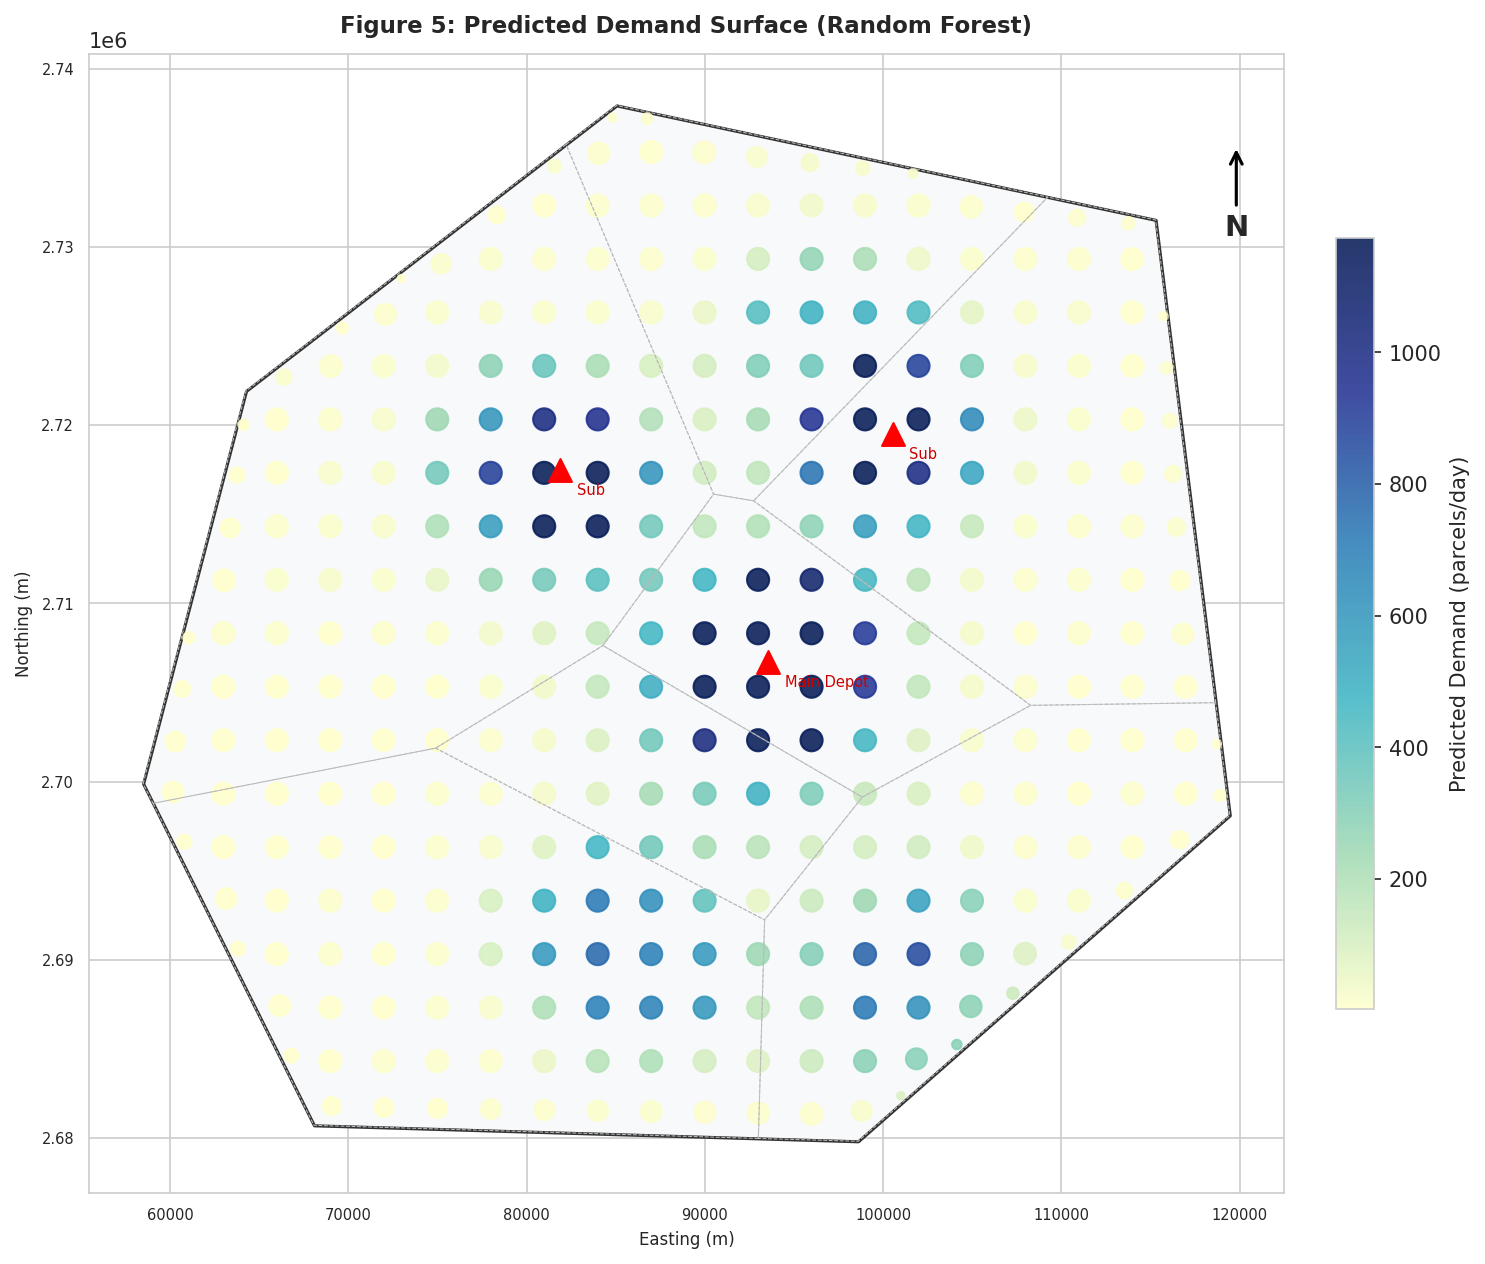

Saved: figures/fig05_predicted_demand_surface.png


In [8]:
# ── Figure 5: Predicted Demand Surface
fig, ax = plt.subplots(figsize=(10,9))
pred_cmap = LinearSegmentedColormap.from_list('pred',
    ['#ffffcc','#a1dab4','#41b6c4','#2c7fb8','#253494','#081d58'])
district_m.plot(ax=ax, color='#f8f9fa', edgecolor='#333', linewidth=1.5, zorder=1)
sc = ax.scatter(grid_m["cx"], grid_m["cy"], c=grid_m['demand_pred'], cmap=pred_cmap,
                s=grid_m.geometry.area/80000, alpha=0.88, zorder=3,
                vmax=grid_m['demand_pred'].quantile(0.95))
upazilas_m.plot(ax=ax, color='none', edgecolor='#bbb', linewidth=0.5, linestyle='--', zorder=4)
depots_m.plot(ax=ax, color='#ff0000', marker='^', markersize=120, zorder=6)
for _, row in depots_m.iterrows():
    ax.annotate(row['name'].split('-')[0].strip(), xy=(row.geometry.x, row.geometry.y),
                xytext=(8,-12), textcoords='offset points', fontsize=7, color='#cc0000')
plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.04, label='Predicted Demand (parcels/day)')
add_furniture(ax, f'Figure 5: Predicted Demand Surface ({best_name})')
plt.tight_layout()
plt.savefig('figures/fig05_predicted_demand_surface.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/fig05_predicted_demand_surface.png")


---
## Section 6: Spatial Hotspot Analysis

Three complementary methods identify statistically significant demand clusters:

1. **KDE**: continuous demand density surface
2. **Getis-Ord Gi***: local spatial statistic (hot/cold spots)
3. **Local Moran's I (LISA)**: spatial cluster/outlier classification (HH, HL, LH, LL)


In [9]:
# ── 6.1 KDE
coords_kde = np.column_stack([grid_m["cx"].values, grid_m["cy"].values])
weights = grid_m['demand_pred'].values
mnx,mny = coords_kde[:,0].min(), coords_kde[:,1].min()
mxx,mxy = coords_kde[:,0].max(), coords_kde[:,1].max()
xi,yi = np.mgrid[mnx:mxx:80j, mny:mxy:80j]
kde = gaussian_kde(coords_kde.T, weights=weights, bw_method=0.15)
zi  = kde(np.vstack([xi.ravel(),yi.ravel()])).reshape(xi.shape)

# ── 6.2 Getis-Ord Gi*
w_knn = KNN.from_dataframe(grid_m, k=6, geom_col='geometry', use_index=False)
gi_star = G_Local(grid_m['demand_pred'].values, w_knn, transform='R', star=True)
grid_m['gi_z'] = gi_star.Zs
grid_m['gi_p'] = gi_star.p_sim
grid_m['gi_class'] = 'Not Significant'
grid_m.loc[(grid_m.gi_z>2.576)&(grid_m.gi_p<0.01),'gi_class'] = 'Hot Spot (99%)'
grid_m.loc[(grid_m.gi_z>1.96) &(grid_m.gi_p<0.05)&(grid_m.gi_class=='Not Significant'),'gi_class'] = 'Hot Spot (95%)'
grid_m.loc[(grid_m.gi_z<-2.576)&(grid_m.gi_p<0.01),'gi_class'] = 'Cold Spot (99%)'
grid_m.loc[(grid_m.gi_z<-1.96) &(grid_m.gi_p<0.05)&(grid_m.gi_class=='Not Significant'),'gi_class'] = 'Cold Spot (95%)'

# ── 6.3 LISA
moran_local = Moran_Local(grid_m['demand_pred'].values, w_knn, seed=SEED)
grid_m['lisa_q'] = moran_local.q
grid_m['lisa_p'] = moran_local.p_sim
grid_m['lisa_sig'] = grid_m['lisa_p'] < 0.05
labels = {1:'HH',2:'LH',3:'LL',4:'HL'}
grid_m['lisa_class'] = grid_m.apply(lambda r: labels.get(r.lisa_q,'') if r.lisa_sig else 'NS', axis=1)

mi = Moran(grid_m['demand_pred'].values, w_knn)
print(f"Global Moran's I = {mi.I:.4f}  (p = {mi.p_sim:.4f})")
print("Gi* distribution:", grid_m['gi_class'].value_counts().to_dict())
print("LISA distribution:", grid_m['lisa_class'].value_counts().to_dict())


Global Moran's I = 0.7121  (p = 0.0010)
Gi* distribution: {'Not Significant': 316, 'Hot Spot (99%)': 8, 'Hot Spot (95%)': 3}
LISA distribution: {'NS': 150, 'LL': 140, 'HH': 37}


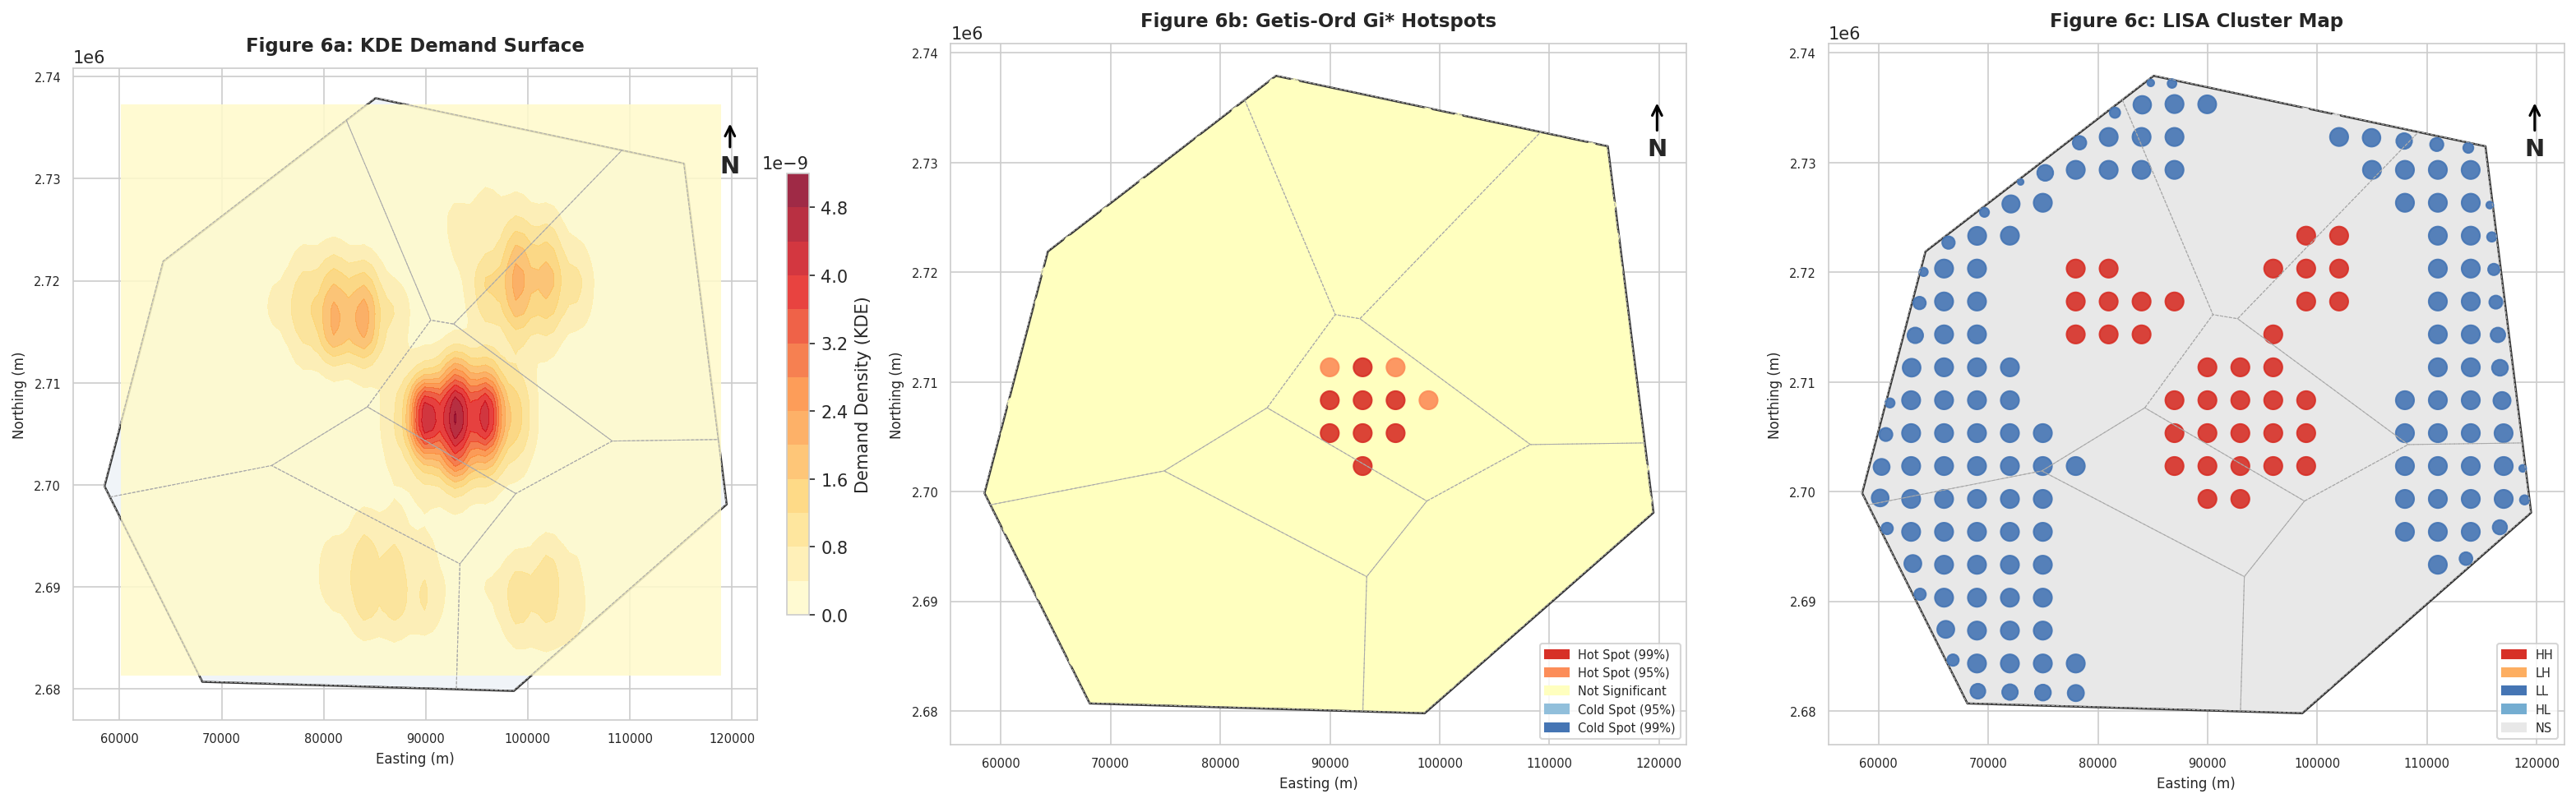

Saved: figures/fig06_hotspot_analysis.png
Exported: outputs/csv/hotspot_results.csv


In [10]:
# ── Figure 6: Hotspot Analysis
fig, axes = plt.subplots(1,3, figsize=(21,8))

gi_colors = {'Hot Spot (99%)':'#d73027','Hot Spot (95%)':'#fc8d59',
             'Not Significant':'#ffffbf','Cold Spot (95%)':'#91bfdb','Cold Spot (99%)':'#4575b4'}
lisa_colors = {'HH':'#d73027','LH':'#fdae61','LL':'#4575b4','HL':'#74add1','NS':'#e8e8e8'}
kde_cmap = LinearSegmentedColormap.from_list('kde',['#ffffd9','#fed976','#fd8d3c','#e31a1c','#800026'])

# KDE
ax = axes[0]
district_m.plot(ax=ax, color='#f0f4f8', edgecolor='#333', linewidth=1.2, zorder=1)
im = ax.contourf(xi, yi, zi, levels=15, cmap=kde_cmap, alpha=0.85, zorder=2)
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04, label='Demand Density (KDE)')
upazilas_m.plot(ax=ax, color='none', edgecolor='#aaa', linewidth=0.5, linestyle='--', zorder=3)
add_furniture(ax, 'Figure 6a: KDE Demand Surface')

# Gi*
ax = axes[1]
district_m.plot(ax=ax, color='#ffffbf', edgecolor='#333', linewidth=1.2, zorder=1)
ax.scatter(grid_m["cx"], grid_m["cy"], c=grid_m['gi_class'].map(gi_colors),
           s=grid_m.geometry.area/80000, zorder=3, alpha=0.9)
patches = [mpatches.Patch(color=c,label=l) for l,c in gi_colors.items()]
ax.legend(handles=patches, loc='lower right', fontsize=7)
upazilas_m.plot(ax=ax, color='none', edgecolor='#aaa', linewidth=0.5, linestyle='--', zorder=4)
add_furniture(ax, 'Figure 6b: Getis-Ord Gi* Hotspots')

# LISA
ax = axes[2]
district_m.plot(ax=ax, color='#e8e8e8', edgecolor='#333', linewidth=1.2, zorder=1)
ax.scatter(grid_m["cx"], grid_m["cy"], c=grid_m['lisa_class'].map(lisa_colors),
           s=grid_m.geometry.area/80000, zorder=3, alpha=0.9)
lisa_patches = [mpatches.Patch(color=c,label=l) for l,c in lisa_colors.items()]
ax.legend(handles=lisa_patches, loc='lower right', fontsize=7)
upazilas_m.plot(ax=ax, color='none', edgecolor='#aaa', linewidth=0.5, linestyle='--', zorder=4)
add_furniture(ax, 'Figure 6c: LISA Cluster Map')

plt.tight_layout()
plt.savefig('figures/fig06_hotspot_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/fig06_hotspot_analysis.png")

grid_m[['cell_id','cx','cy','demand_pred','gi_z','gi_p','gi_class','lisa_class']].to_csv(
    'outputs/csv/hotspot_results.csv', index=False)
print("Exported: outputs/csv/hotspot_results.csv")


---
## Section 7: Route Optimisation

A synthetic road graph is constructed from urban centre nodes and random junctions. A nearest-neighbour VRP heuristic with capacity (150 units) and maximum distance (100 km) constraints generates optimised multi-vehicle routes. Results are compared with a traditional sequential-assignment baseline.


In [11]:
# ── 7.1 Build Road Graph
rng2 = np.random.default_rng(SEED)
G = nx.Graph()
node_coords = {}

for i, row in urban_m.iterrows():
    G.add_node(i, x=row.geometry.x, y=row.geometry.y)
    node_coords[i] = (row.geometry.x, row.geometry.y)

mnx2,mny2,mxx2,mxy2 = district_m.geometry.unary_union.bounds
junc_start = len(urban_m)
jid = junc_start
for _ in range(40):
    x,y = rng2.uniform(mnx2,mxx2), rng2.uniform(mny2,mxy2)
    if district_m.geometry.unary_union.contains(Point(x,y)):
        G.add_node(jid, x=x, y=y); node_coords[jid]=(x,y); jid+=1

nc_arr = np.array(list(node_coords.values()))
nc_keys = list(node_coords.keys())
tree_g = cKDTree(nc_arr)
for i,nid in enumerate(nc_keys):
    ds,idxs = tree_g.query(nc_arr[i], k=5)
    for d,idx in zip(ds[1:],idxs[1:]):
        nbr = nc_keys[idx]
        spd = rng2.uniform(20,50)
        dk  = d/1000
        G.add_edge(nid, nbr, weight=dk, travel_time=dk/spd*60)

print(f"Road graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

# Map delivery zones to graph nodes
top_demand = grid_m.nlargest(30,'demand_pred').copy()
delivery_nodes = []
for _,row in top_demand.iterrows():
    _d,ni = tree_g.query([row["cx"], row.cy])
    n = nc_keys[ni]
    if G.has_node(n): delivery_nodes.append(n)
delivery_nodes = list(set(delivery_nodes))

# Depot node
dep_coord = np.array([depots_m.iloc[0].geometry.x, depots_m.iloc[0].geometry.y])
_,dep_ni  = tree_g.query(dep_coord)
depot_node = nc_keys[dep_ni]
print(f"Delivery zones: {len(delivery_nodes)} | Depot node: {depot_node}")


Road graph: 46 nodes, 114 edges
Delivery zones: 13 | Depot node: 0


In [12]:
# ── 7.2 VRP Nearest-Neighbour Heuristic
def vrp_nn(G, depot, deliveries, capacity=150, max_dist=100):
    routes = []
    unvisited = list(deliveries)
    rng3 = np.random.default_rng(42)
    while unvisited:
        route=[depot]; rd=0; rc=0; curr=depot
        while unvisited:
            cands=[]
            for node in unvisited:
                try:
                    d=nx.shortest_path_length(G,curr,node,weight='weight')
                    dback=nx.shortest_path_length(G,node,depot,weight='weight')
                    dem=rng3.integers(5,25)
                    if rc+dem<=capacity and rd+d+dback<=max_dist:
                        cands.append((d,node,dem))
                except nx.NetworkXNoPath: continue
            if not cands: break
            cands.sort(key=lambda x:x[0])
            bd,bn,bdem=cands[0]
            route.append(bn); rc+=bdem; rd+=bd; curr=bn
            unvisited.remove(bn)
        route.append(depot)
        dist_total = sum(
            nx.shortest_path_length(G,route[i],route[i+1],weight='weight')
            for i in range(len(route)-1) if G.has_node(route[i]) and G.has_node(route[i+1]))
        routes.append({'route':route,'distance_km':dist_total,'n_stops':len(route)-2})
    return routes

def trad_routes(G, depot, deliveries, size=8):
    routes=[]
    for i in range(0,len(deliveries),size):
        batch=deliveries[i:i+size]
        route=[depot]+batch+[depot]
        d=sum(nx.shortest_path_length(G,route[j],route[j+1],weight='weight')
              for j in range(len(route)-1)
              if G.has_node(route[j]) and G.has_node(route[j+1]))
        routes.append({'route':route,'distance_km':d,'n_stops':len(batch)})
    return routes

opt_routes  = vrp_nn(G, depot_node, delivery_nodes)
trad_r = trad_routes(G, depot_node, delivery_nodes, size=8)

def route_metrics(routes, fuel_lkm=0.12, cost_bdt_l=115):
    td   = sum(r['distance_km'] for r in routes)
    fuel = td*fuel_lkm
    cost = fuel*cost_bdt_l
    return {'n_vehicles':len(routes),'total_dist_km':td,
            'fuel_litres':fuel,'op_cost_bdt':cost,
            'avg_time_min':td/35*60}

mt = route_metrics(trad_r)
mo = route_metrics(opt_routes)
dist_save = (1-mo['total_dist_km']/mt['total_dist_km'])*100
cost_save = (1-mo['op_cost_bdt']/mt['op_cost_bdt'])*100
print(f"Trad: {mt['n_vehicles']} vehicles | {mt['total_dist_km']:.1f} km | BDT {mt['op_cost_bdt']:.0f}")
print(f"Opt:  {mo['n_vehicles']} vehicles | {mo['total_dist_km']:.1f} km | BDT {mo['op_cost_bdt']:.0f}")
print(f"Distance saving: {dist_save:.1f}%  |  Cost saving: {cost_save:.1f}%")

pd.DataFrame([{**{'Scenario':'Traditional'},**mt},{**{'Scenario':'Optimised'},**mo}]).to_csv(
    'outputs/csv/route_metrics.csv', index=False)


Trad: 2 vehicles | 267.0 km | BDT 3685
Opt:  2 vehicles | 149.5 km | BDT 2063
Distance saving: 44.0%  |  Cost saving: 44.0%


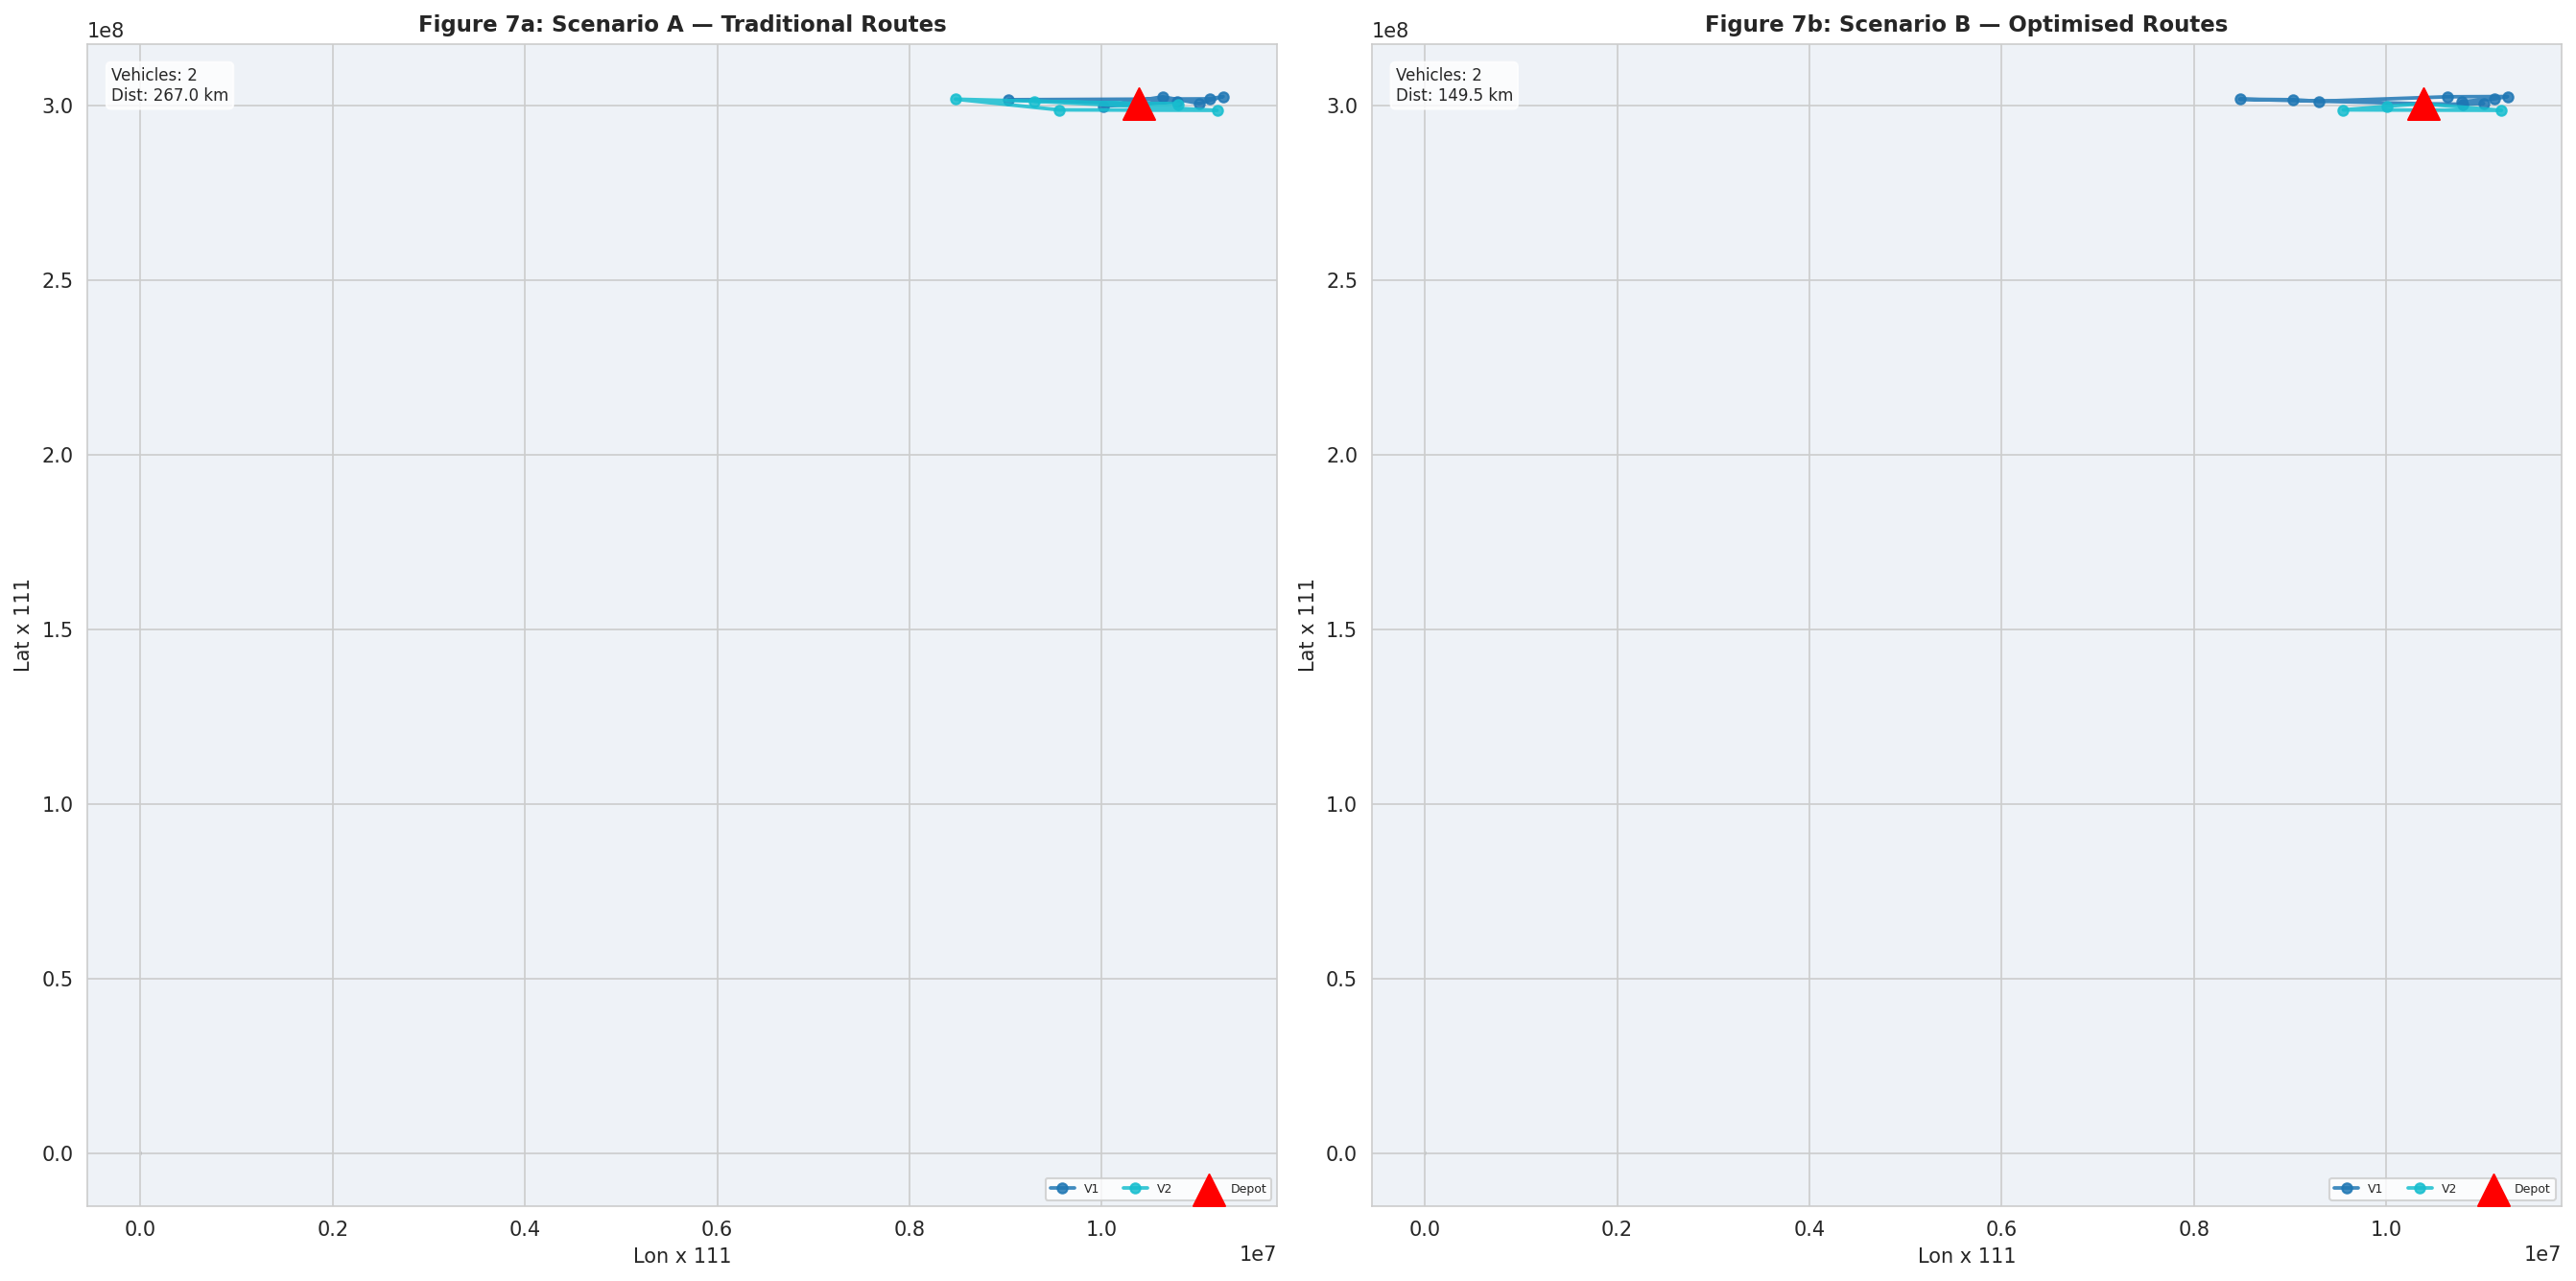

Saved: figures/fig07_optimised_routes.png


In [13]:
# ── Figure 7: Route Comparison
fig, axes = plt.subplots(1,2, figsize=(18,9))
bx=[c[0]*111 for c in natore_coords]; by=[c[1]*111 for c in natore_coords]

for ax, routes, title, ms in zip(axes,[trad_r,opt_routes],
    ['Figure 7a: Scenario A — Traditional Routes','Figure 7b: Scenario B — Optimised Routes'],
    [mt,mo]):
    ax.set_facecolor('#eef2f7')
    ax.fill(bx, by, color='#f5f0eb', edgecolor='#555', linewidth=1.5, zorder=1)
    colors_r = plt.cm.tab10(np.linspace(0,1,len(routes)))
    for k, ri in enumerate(routes):
        route = [n for n in ri['route'] if n in node_coords]
        rx=[node_coords[n][0]*111 for n in route]
        ry=[node_coords[n][1]*111 for n in route]
        ax.plot(rx,ry,'-o',color=colors_r[k],linewidth=1.8,markersize=5,alpha=0.85,label=f'V{k+1}')
    dx=depots_m.iloc[0].geometry.x*111; dy=depots_m.iloc[0].geometry.y*111
    ax.scatter([dx],[dy],s=250,color='red',marker='^',zorder=5,label='Depot')
    ax.set_title(title,fontweight='bold',fontsize=11)
    ax.set_xlabel('Lon x 111'); ax.set_ylabel('Lat x 111')
    ax.legend(fontsize=6,ncol=3,loc='lower right')
    ax.text(0.02,0.98,f"Vehicles: {ms['n_vehicles']}\nDist: {ms['total_dist_km']:.1f} km",
            transform=ax.transAxes,fontsize=8,va='top',
            bbox=dict(boxstyle='round',fc='white',alpha=0.8))

plt.tight_layout()
plt.savefig('figures/fig07_optimised_routes.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/fig07_optimised_routes.png")


---
## Section 8: Depot Location Optimisation

The **p-Median** model (p=3) minimises the weighted sum of distances between demand zones and selected depot facilities. Coverage analysis evaluates the percentage of total predicted demand reachable within an 8 km service radius.


In [14]:
from itertools import combinations

def p_median(demand_gdf, candidate_pts, p=3, n_sample=3000):
    dem_c = np.column_stack([demand_gdf["cx"].values, demand_gdf["cy"].values])
    dem_w = demand_gdf['demand_pred'].values
    cand  = np.array(candidate_pts)
    dist_m = cdist(dem_c, cand)
    best_cost, best_combo = np.inf, None
    rng4 = np.random.default_rng(42)
    combos = [tuple(rng4.choice(len(cand),p,replace=False)) for _ in range(n_sample)]
    for combo in combos:
        cost = (dist_m[:,list(combo)].min(axis=1)*dem_w).sum()
        if cost<best_cost: best_cost=cost; best_combo=combo
    return best_combo, best_cost

candidates = list(zip(grid_m["cx"].values, grid_m["cy"].values))
best_combo, best_cost = p_median(grid_m, candidates, p=3)
print(f"p-Median cost: {best_cost:.0f}")

opt_depot_coords = np.array(candidates)[list(best_combo)]
opt_depots_gdf = gpd.GeoDataFrame({
    'depot_id':[f'OPT-D{i+1}' for i in range(3)],
    'geometry':[Point(xy[0],xy[1]) for xy in opt_depot_coords]
}, crs=TARGET_CRS)

# Coverage
thr = 8000
grid_m['cov_exist'] = grid_m.geometry.apply(
    lambda g: depots_m.distance(g.centroid).min() <= thr)
grid_m['cov_opt'] = grid_m.geometry.apply(
    lambda g: opt_depots_gdf.distance(g.centroid).min() <= thr)
cov_e = (grid_m.cov_exist*grid_m.demand_pred).sum()/grid_m.demand_pred.sum()*100
cov_o = (grid_m.cov_opt  *grid_m.demand_pred).sum()/grid_m.demand_pred.sum()*100
print(f"Coverage: Existing={cov_e:.1f}%  Optimised={cov_o:.1f}%")

grid_m['depot_suitability'] = (
    grid_m['demand_pred']/grid_m['demand_pred'].max()*0.4 +
    grid_m['road_density']/grid_m['road_density'].max()*0.3 +
    grid_m['urban_idx']/grid_m['urban_idx'].max()*0.2 +
    (1-grid_m['dist_depot_m']/grid_m['dist_depot_m'].max())*0.1)


p-Median cost: 656684282
Coverage: Existing=72.5%  Optimised=58.6%


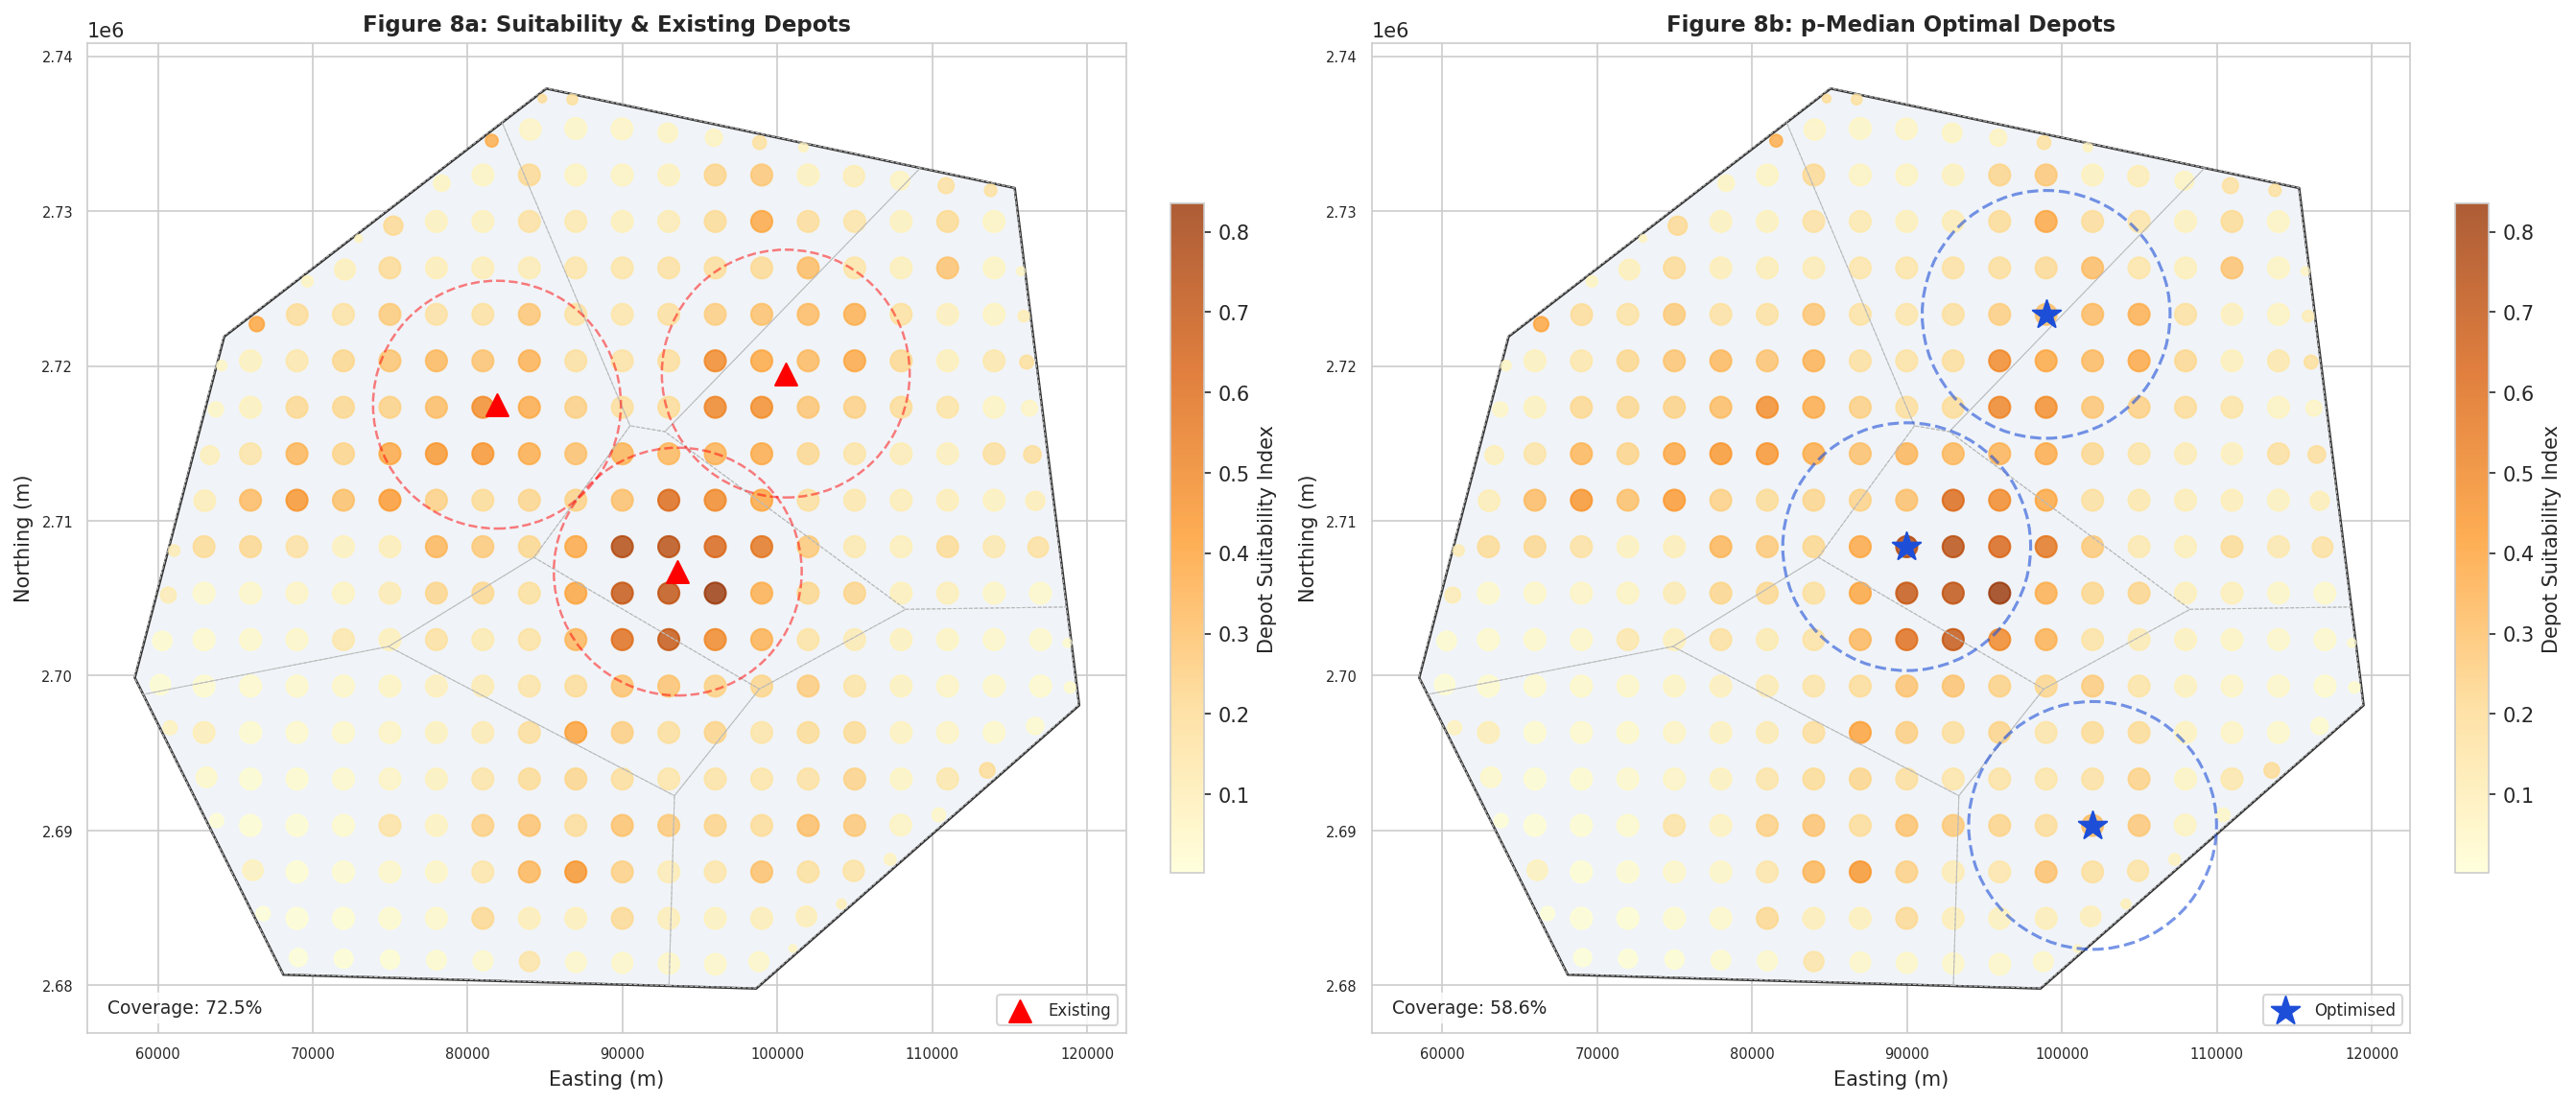

Saved: figures/fig08_depot_optimisation.png


In [15]:
# ── Figure 8: Depot Optimisation
fig, axes = plt.subplots(1,2, figsize=(18,9))
suit_cmap = LinearSegmentedColormap.from_list('suit',['#ffffd4','#fed98e','#fe9929','#d95f0e','#993404'])

for i,(ax,show_opt,title,cov) in enumerate(zip(axes,[False,True],
    ['Figure 8a: Suitability & Existing Depots','Figure 8b: p-Median Optimal Depots'],
    [cov_e, cov_o])):
    district_m.plot(ax=ax, color='#f0f4f8', edgecolor='#333', linewidth=1.2, zorder=1)
    sc = ax.scatter(grid_m["cx"], grid_m["cy"], c=grid_m['depot_suitability'],
                    cmap=suit_cmap, s=grid_m.geometry.area/80000, alpha=0.8, zorder=2)
    upazilas_m.plot(ax=ax, color='none', edgecolor='#bbb', linewidth=0.5, linestyle='--', zorder=3)
    if show_opt:
        for _, row in opt_depots_gdf.iterrows():
            circle=plt.Circle((row.geometry.x,row.geometry.y),thr,
                               fill=False,edgecolor='#1d4ed8',lw=1.5,ls='--',alpha=0.6,zorder=4)
            ax.add_patch(circle)
        opt_depots_gdf.plot(ax=ax,color='#1d4ed8',marker='*',markersize=220,zorder=5,label='Optimised')
    else:
        for _, row in depots_m.iterrows():
            circle=plt.Circle((row.geometry.x,row.geometry.y),thr,
                               fill=False,edgecolor='red',lw=1.2,ls='--',alpha=0.5,zorder=4)
            ax.add_patch(circle)
        depots_m.plot(ax=ax,color='red',marker='^',markersize=120,zorder=5,label='Existing')
    ax.legend(fontsize=8,loc='lower right')
    plt.colorbar(sc,ax=ax,fraction=0.03,pad=0.04,label='Depot Suitability Index')
    ax.text(0.02,0.02,f"Coverage: {cov:.1f}%",transform=ax.transAxes,fontsize=9,
            bbox=dict(boxstyle='round',fc='white',alpha=0.8))
    ax.set_title(title,fontweight='bold',fontsize=11)
    ax.set_xlabel('Easting (m)'); ax.set_ylabel('Northing (m)')
    ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('figures/fig08_depot_optimisation.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/fig08_depot_optimisation.png")


---
## Section 9: Results and Discussion

### 9.1 Model Performance Summary


In [16]:
print("=" * 70)
print("   TABLE 1 — GeoAI MODEL PERFORMANCE COMPARISON")
print("=" * 70)
print(f"{'Model':<22} {'RMSE':>8} {'MAE':>8} {'MAPE%':>8} {'R2':>8} {'CV R2':>8}")
print("-" * 70)
for name, r in results.items():
    print(f"{name:<22} {r['RMSE']:>8.2f} {r['MAE']:>8.2f} {r['MAPE']:>8.2f} {r['R2']:>8.4f} {r['CV_R2']:>8.4f}")
print("=" * 70)
print(f"\nBest model: {best_name}")

print("\n" + "=" * 60)
print("   TABLE 2 — ROUTE SCENARIO COMPARISON")
print("=" * 60)
print(f"  {'Metric':<25} {'Traditional':>15} {'Optimised':>15}")
print("-" * 60)
for metric, tv, ov in [
    ('Vehicles Deployed', mt['n_vehicles'],    mo['n_vehicles']),
    ('Total Distance (km)', f"{mt['total_dist_km']:.1f}", f"{mo['total_dist_km']:.1f}"),
    ('Fuel (L)',             f"{mt['fuel_litres']:.1f}",  f"{mo['fuel_litres']:.1f}"),
    ('Op. Cost (BDT)',       f"{mt['op_cost_bdt']:.0f}",  f"{mo['op_cost_bdt']:.0f}"),
]:
    print(f"  {metric:<25} {str(tv):>15} {str(ov):>15}")
print(f"\n  Distance saving: {dist_save:.1f}%  |  Cost saving: {cost_save:.1f}%")
print("=" * 60)

print("\n" + "=" * 55)
print("   TABLE 3 — DEPOT COVERAGE ANALYSIS")
print("=" * 55)
print(f"  Service radius:         {thr/1000:.0f} km")
print(f"  Existing coverage:      {cov_e:.1f}%")
print(f"  Optimised coverage:     {cov_o:.1f}%")
print(f"  Improvement:            {cov_o-cov_e:.1f} pp")
print("=" * 55)

print("\n" + "=" * 55)
print("   TABLE 4 — SPATIAL AUTOCORRELATION")
print("=" * 55)
print(f"  Global Moran's I:  {mi.I:.4f}  (p = {mi.p_sim:.4f})")
hot99 = (grid_m['gi_class']=='Hot Spot (99%)').sum()
hot95 = (grid_m['gi_class']=='Hot Spot (95%)').sum()
print(f"  Hot Spot cells (95%): {hot95}  |  (99%): {hot99}")
print("=" * 55)


   TABLE 1 — GeoAI MODEL PERFORMANCE COMPARISON
Model                      RMSE      MAE    MAPE%       R2    CV R2
----------------------------------------------------------------------
Random Forest            212.92    98.32    78.65   0.8744   0.6060
XGBoost                  260.20   113.47    77.48   0.8124   0.5659
Gradient Boosting        217.58   101.85    79.34   0.8688   0.6089

Best model: Random Forest

   TABLE 2 — ROUTE SCENARIO COMPARISON
  Metric                        Traditional       Optimised
------------------------------------------------------------
  Vehicles Deployed                       2               2
  Total Distance (km)                 267.0           149.5
  Fuel (L)                             32.0            17.9
  Op. Cost (BDT)                       3685            2063

  Distance saving: 44.0%  |  Cost saving: 44.0%

   TABLE 3 — DEPOT COVERAGE ANALYSIS
  Service radius:         8 km
  Existing coverage:      72.5%
  Optimised coverage:     58.6%

---
## Section 10: Integrated Decision-Support Map (Figure 10)

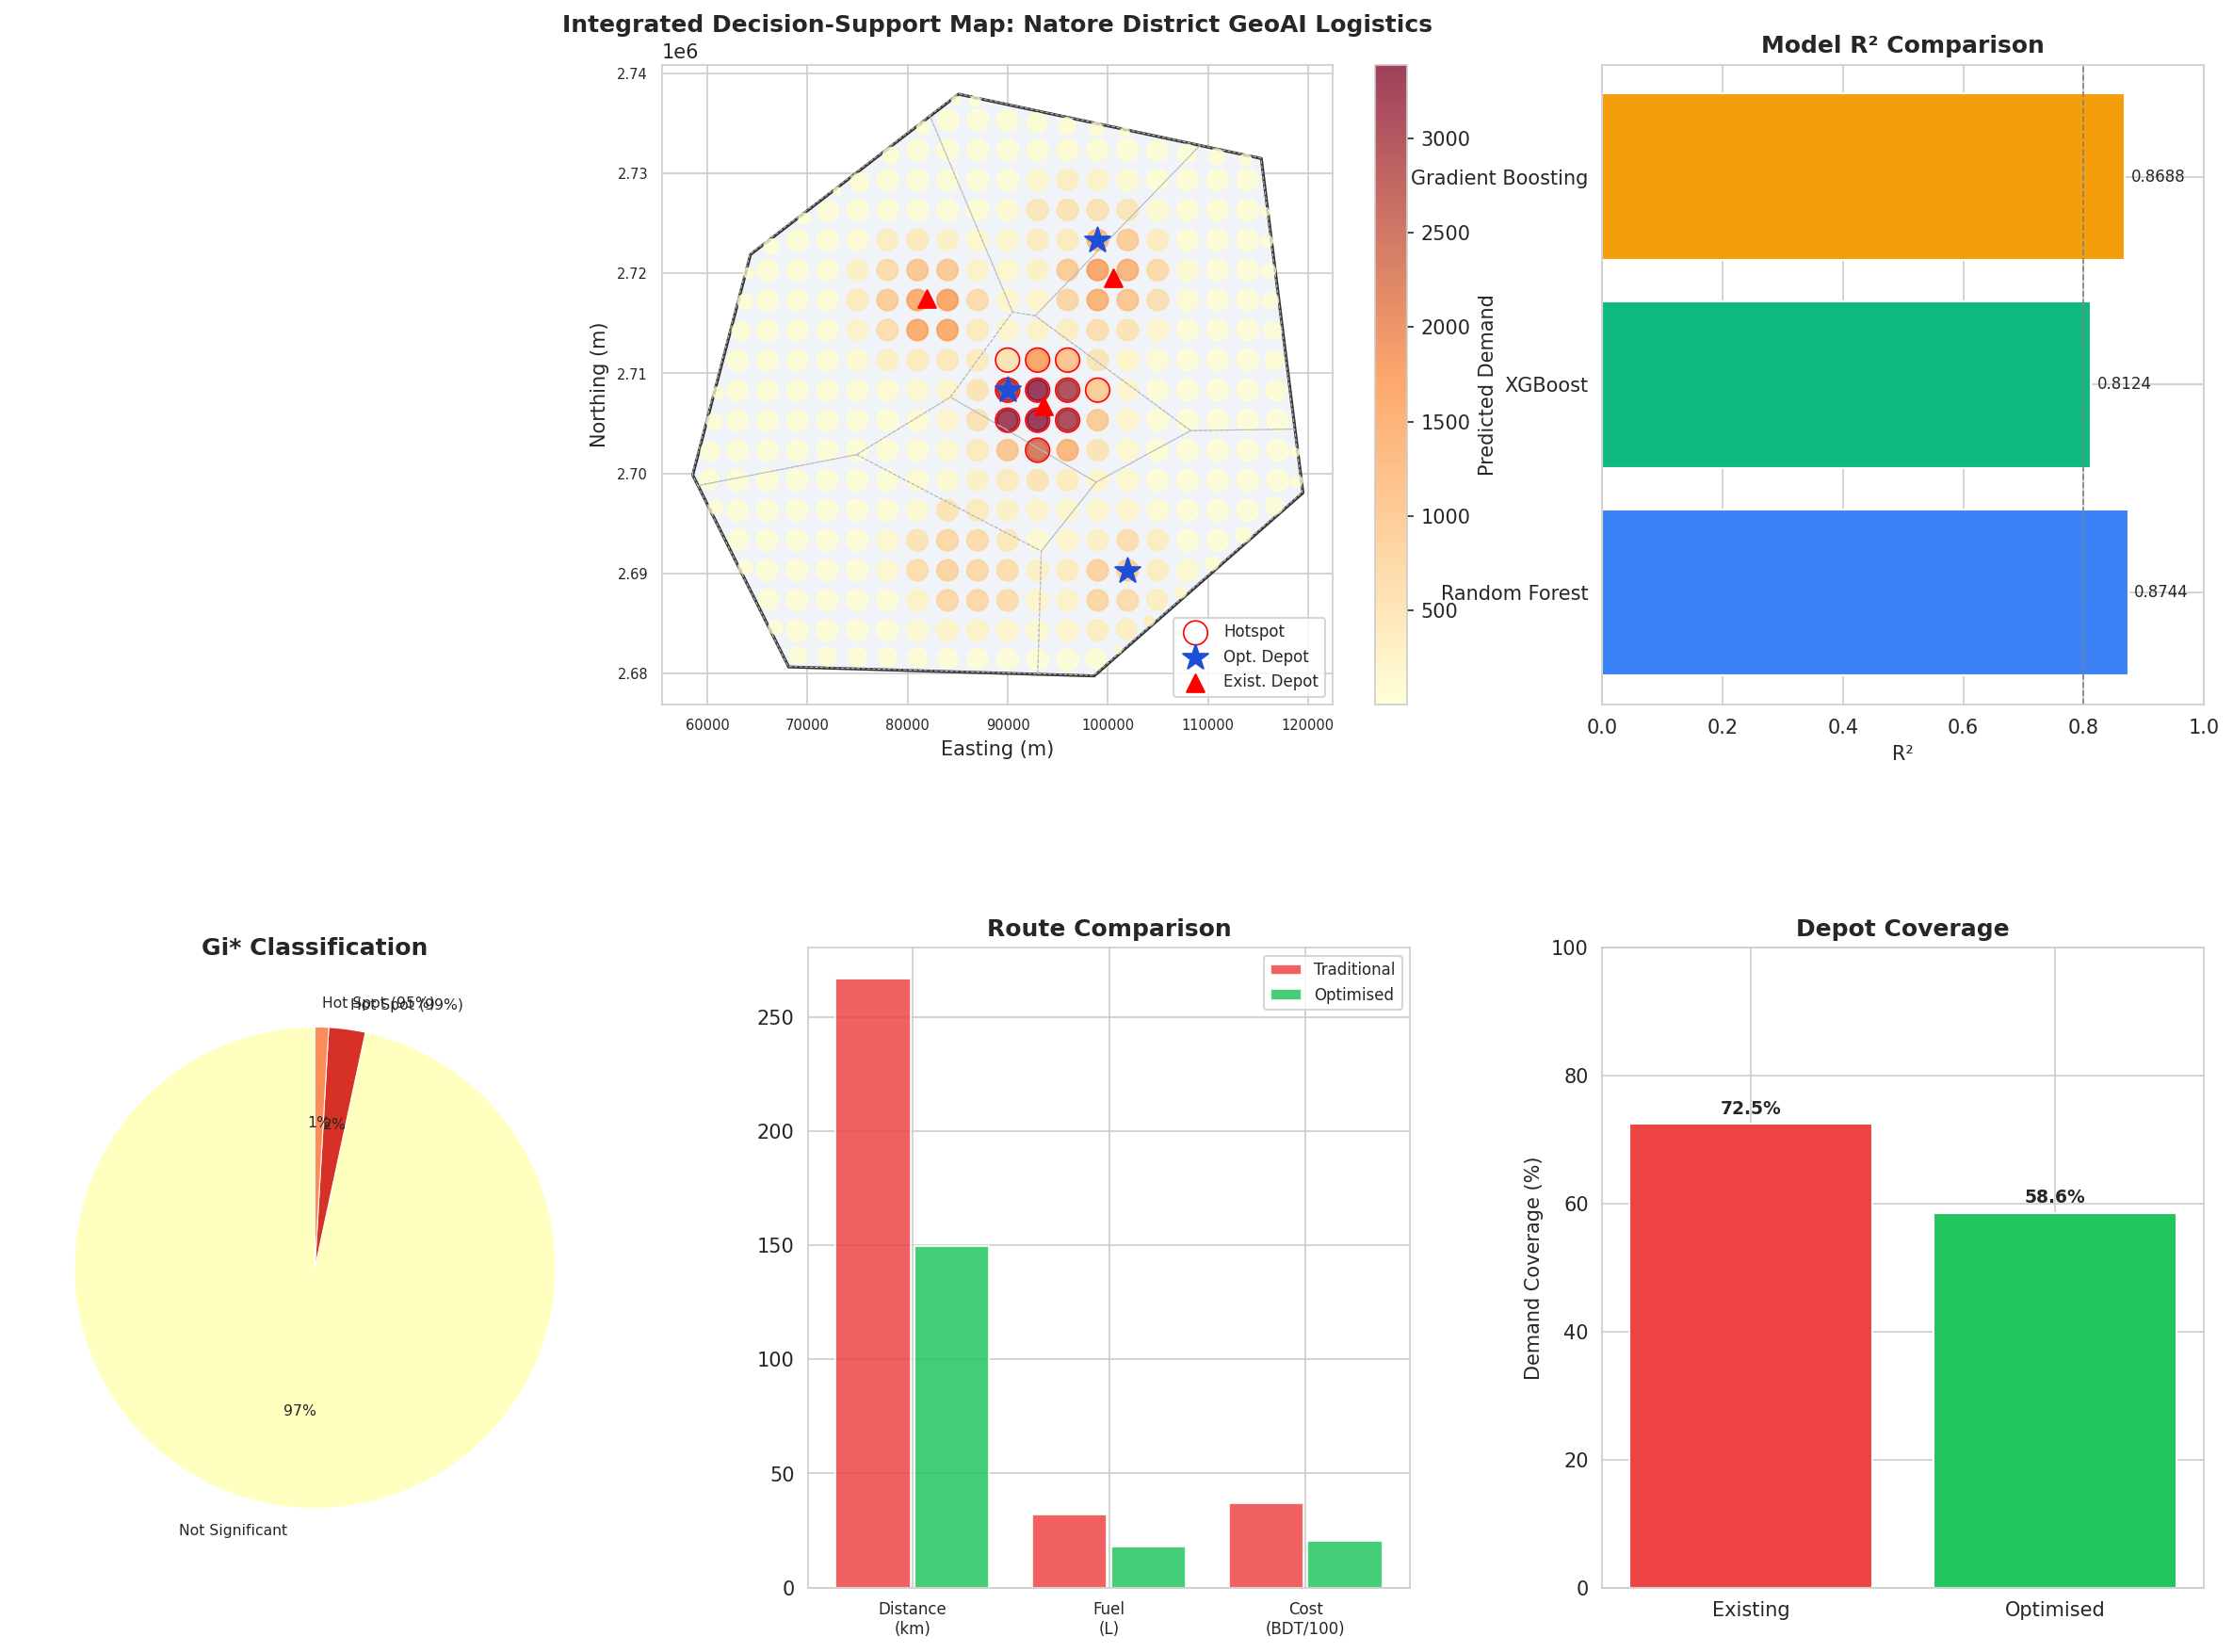

Saved: figures/fig10_integrated_decision_support.png


In [17]:
fig = plt.figure(figsize=(20,14))
gs  = gridspec.GridSpec(2,3,figure=fig,hspace=0.38,wspace=0.32)
ax_map = fig.add_subplot(gs[0,:2])
ax_bar = fig.add_subplot(gs[0,2])
ax_hot = fig.add_subplot(gs[1,0])
ax_rte = fig.add_subplot(gs[1,1])
ax_cov = fig.add_subplot(gs[1,2])

dem_cmap2 = LinearSegmentedColormap.from_list('d',['#ffffcc','#fd8d3c','#800026'])

# Main map
district_m.plot(ax=ax_map, color='#f0f4f8', edgecolor='#333', linewidth=1.5, zorder=1)
sc = ax_map.scatter(grid_m["cx"], grid_m["cy"], c=grid_m['demand_pred'],
                    cmap=dem_cmap2, s=grid_m.geometry.area/80000, alpha=0.75, zorder=2)
hh = grid_m[grid_m['gi_class'].str.contains('Hot',na=False)]
ax_map.scatter(hh["cx"], hh["cy"], s=hh.geometry.area/60000, facecolors='none',
               edgecolors='#ff0000', linewidths=0.8, zorder=4, label='Hotspot')
opt_depots_gdf.plot(ax=ax_map, color='#1d4ed8', marker='*', markersize=180, zorder=6, label='Opt. Depot')
depots_m.plot(ax=ax_map, color='red', marker='^', markersize=80, zorder=5, label='Exist. Depot')
upazilas_m.plot(ax=ax_map, color='none', edgecolor='#bbb', linewidth=0.5, linestyle='--', zorder=3)
plt.colorbar(sc, ax=ax_map, fraction=0.025, pad=0.03, label='Predicted Demand')
ax_map.legend(loc='lower right', fontsize=8)
ax_map.set_title('Integrated Decision-Support Map: Natore District GeoAI Logistics',
                  fontweight='bold', fontsize=12)
ax_map.set_xlabel('Easting (m)'); ax_map.set_ylabel('Northing (m)')
ax_map.tick_params(labelsize=7)

# Model R2
m_names=list(results.keys()); r2s=[results[n]['R2'] for n in m_names]
ax_bar.barh(m_names, r2s, color=['#3b82f6','#10b981','#f59e0b'])
ax_bar.set_xlim(0,1); ax_bar.set_xlabel('R²'); ax_bar.set_title('Model R² Comparison',fontweight='bold')
for i,(n,v) in enumerate(zip(m_names,r2s)):
    ax_bar.text(v+0.01,i,f'{v:.4f}',va='center',fontsize=8)
ax_bar.axvline(0.8,ls='--',color='gray',lw=0.8)

# Gi* pie
gi_vc = grid_m['gi_class'].value_counts()
gc = {'Hot Spot (99%)':'#d73027','Hot Spot (95%)':'#fc8d59',
      'Not Significant':'#ffffbf','Cold Spot (95%)':'#91bfdb','Cold Spot (99%)':'#4575b4'}
ax_hot.pie(gi_vc.values,labels=gi_vc.index,
           colors=[gc.get(l,'gray') for l in gi_vc.index],
           autopct='%1.0f%%',startangle=90,textprops={'fontsize':7.5},
           wedgeprops={'edgecolor':'white','linewidth':0.5})
ax_hot.set_title('Gi* Classification',fontweight='bold')

# Route bar
mn=['Distance\n(km)','Fuel\n(L)','Cost\n(BDT/100)']
tv=[mt['total_dist_km'],mt['fuel_litres'],mt['op_cost_bdt']/100]
ov=[mo['total_dist_km'],mo['fuel_litres'],mo['op_cost_bdt']/100]
xp=np.arange(3)
ax_rte.bar(xp-0.2,tv,0.38,label='Traditional',color='#ef4444',alpha=0.85)
ax_rte.bar(xp+0.2,ov,0.38,label='Optimised',color='#22c55e',alpha=0.85)
ax_rte.set_xticks(xp); ax_rte.set_xticklabels(mn,fontsize=8)
ax_rte.legend(fontsize=8); ax_rte.set_title('Route Comparison',fontweight='bold')

# Coverage
ax_cov.bar(['Existing','Optimised'],[cov_e,cov_o],color=['#ef4444','#22c55e'])
ax_cov.set_ylim(0,100); ax_cov.set_ylabel('Demand Coverage (%)'); ax_cov.set_title('Depot Coverage',fontweight='bold')
for i,(v) in enumerate([cov_e,cov_o]):
    ax_cov.text(i,v+1.5,f'{v:.1f}%',ha='center',fontsize=9,fontweight='bold')

plt.savefig('figures/fig10_integrated_decision_support.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: figures/fig10_integrated_decision_support.png")


---
## Section 11: Interactive WebGIS Dashboard

In [18]:
m_map = folium.Map(location=[24.42,88.99], zoom_start=10,
                   tiles='CartoDB positron',
                   attr='CartoDB | OpenStreetMap')

# Upazilas
upz_layer = folium.FeatureGroup(name='Upazilas', show=True)
for _, row in upazilas.iterrows():
    sim_geo = gpd.GeoDataFrame(geometry=[row.geometry], crs='EPSG:4326')
    folium.GeoJson(sim_geo.__geo_interface__,
        style_function=lambda x: {'fillColor':'#a8d8ea','color':'#555','weight':1,'fillOpacity':0.15},
        tooltip=folium.Tooltip(row['upazila'])).add_to(upz_layer)
upz_layer.add_to(m_map)

# Heatmap
heat_layer = folium.FeatureGroup(name='Demand Heatmap', show=True)
HeatMap([[r.lat,r.lon,r.demand_vol] for _,r in demand_pts.iterrows()],
        radius=15, blur=20, gradient={0.2:'blue',0.5:'lime',1.0:'red'}).add_to(heat_layer)
heat_layer.add_to(m_map)

# Urban centres
uc_layer = folium.FeatureGroup(name='Urban Centres', show=True)
for _, row in urban_centres.iterrows():
    folium.CircleMarker([row.geometry.y,row.geometry.x],
        radius=max(6,int(row.population/1500)), color='#e63946',
        fill=True, fill_color='#e63946', fill_opacity=0.7,
        popup=folium.Popup(f"<b>{row['name']}</b><br>Pop: {row.population:,}",max_width=180),
        tooltip=row['name']).add_to(uc_layer)
uc_layer.add_to(m_map)

# Existing depots
dep_layer = folium.FeatureGroup(name='Existing Depots', show=True)
for _, row in depots.iterrows():
    folium.Marker([row.geometry.y,row.geometry.x],
        popup=folium.Popup(f"<b>{row['name']}</b><br>Cap: {row.capacity}/day",max_width=180),
        tooltip=row['name'],
        icon=folium.Icon(color='red',icon='industry',prefix='fa')).add_to(dep_layer)
dep_layer.add_to(m_map)

# Optimised depots
opt_dep_layer = folium.FeatureGroup(name='Optimised Depots (p-Median)', show=True)
for _, row in opt_depots_gdf.to_crs('EPSG:4326').iterrows():
    folium.Marker([row.geometry.y,row.geometry.x],
        popup=folium.Popup(f"<b>{row.depot_id}</b><br>p-Median Optimal",max_width=150),
        tooltip=row.depot_id,
        icon=folium.Icon(color='blue',icon='star',prefix='fa')).add_to(opt_dep_layer)
opt_dep_layer.add_to(m_map)

# Predicted demand grid
pred_layer = folium.FeatureGroup(name='Predicted Demand Grid', show=False)
norm_pred = (grid_m['demand_pred']-grid_m['demand_pred'].min())/(grid_m['demand_pred'].max()-grid_m['demand_pred'].min())
for _, row in grid_m.to_crs('EPSG:4326').iterrows():
    val = norm_pred[row.name]; r=int(val*255); g=int((1-val)*150)
    clr = f'#{r:02x}{g:02x}32'
    cx4 = row.geometry.centroid
    folium.CircleMarker([cx4.y,cx4.x], radius=5, color=clr,
        fill=True, fill_color=clr, fill_opacity=0.65,
        tooltip=f"{row['demand_pred']:.0f} parcels/day").add_to(pred_layer)
pred_layer.add_to(m_map)

# Gi* hotspots
hot_layer = folium.FeatureGroup(name='Gi* Hotspots', show=False)
gi_cm = {'Hot Spot (99%)':'#d73027','Hot Spot (95%)':'#fc8d59',
          'Cold Spot (95%)':'#91bfdb','Cold Spot (99%)':'#4575b4'}
for _, row in grid_m[grid_m['gi_class']!='Not Significant'].to_crs('EPSG:4326').iterrows():
    c4 = row.geometry.centroid
    col = gi_cm.get(row.gi_class,'#999')
    folium.CircleMarker([c4.y,c4.x], radius=7, color=col,
        fill=True, fill_color=col, fill_opacity=0.75,
        tooltip=f"{row.gi_class} | Z={row.gi_z:.2f}").add_to(hot_layer)
hot_layer.add_to(m_map)

# Optimised routes
rte_layer = folium.FeatureGroup(name='Optimised Delivery Routes', show=True)
rcols=['#e63946','#457b9d','#2a9d8f','#e9c46a','#f4a261','#264653']
for k, ri in enumerate(opt_routes[:6]):
    route=[n for n in ri['route'] if n in node_coords]
    coords=[[node_coords[n][1],node_coords[n][0]] for n in route]
    if len(coords)>1:
        folium.PolyLine(coords, color=rcols[k%6], weight=3.5, opacity=0.85,
            popup=f"Route {k+1} | {ri['distance_km']:.1f} km | {ri['n_stops']} stops",
            tooltip=f"Vehicle {k+1}").add_to(rte_layer)
rte_layer.add_to(m_map)

folium.LayerControl(collapsed=False).add_to(m_map)
MeasureControl(position='topleft', primary_length_unit='kilometers').add_to(m_map)

legend_html = (
    "<div style='position:fixed;bottom:30px;right:10px;z-index:9999;"
    "background:white;padding:12px;border-radius:8px;"
    "box-shadow:2px 2px 8px rgba(0,0,0,0.3);font-size:12px;'>"
    "<b>Natore GeoAI Logistics</b><br><hr style='margin:4px 0;'>"
    "<span style='background:#d73027;color:white;padding:1px 6px;border-radius:3px;'>H</span> Hot Spot 99%<br>"
    "<span style='background:#fc8d59;color:white;padding:1px 6px;border-radius:3px;'>H</span> Hot Spot 95%<br>"
    "<span style='background:#4575b4;color:white;padding:1px 6px;border-radius:3px;'>C</span> Cold Spot<br>"
    "Red triangle = Existing Depot | Blue star = Optimal<br>"
    "</div>"
)
m_map.get_root().html.add_child(folium.Element(legend_html))

title_html = (
    "<div style='position:fixed;top:10px;left:50%;transform:translateX(-50%);"
    "z-index:9999;background:rgba(255,255,255,0.92);padding:10px 20px;"
    "border-radius:8px;box-shadow:2px 2px 8px rgba(0,0,0,0.25);text-align:center;'>"
    "<b style='font-size:15px;'>GeoAI Logistics Dashboard — Natore District, Bangladesh</b><br>"
    "<span style='font-size:11px;color:#555;'>Demand Prediction | Hotspot Analysis | Route Optimisation</span>"
    "</div>"
)
m_map.get_root().html.add_child(folium.Element(title_html))

m_map.save('outputs/html/dashboard.html')
print("Dashboard saved: outputs/html/dashboard.html")


Dashboard saved: outputs/html/dashboard.html


---
## Section 12: Data Exports

In [19]:
# CSV
grid_m[['cell_id','cx','cy']+FEATURES+['demand_obs','demand_pred','gi_class','lisa_class','depot_suitability']].to_csv(
    'outputs/csv/predicted_demand.csv', index=False)

# GeoJSON
demand_pts[['demand_vol','zone_type','lat','lon','geometry']].to_file(
    'outputs/geojson/demand_points.geojson', driver='GeoJSON')

route_lines=[]
for k,ri in enumerate(opt_routes):
    r=[n for n in ri['route'] if n in node_coords]
    if len(r)>1:
        cds=[(node_coords[n][0]/1000,node_coords[n][1]/1000) for n in r]
        # store as point list in properties instead
        route_lines.append({'route_id':k+1,'distance_km':ri['distance_km'],
                            'n_stops':ri['n_stops'],
                            'geometry':LineString(cds) if len(cds)>=2 else Point(cds[0])})
if route_lines:
    gpd.GeoDataFrame(route_lines,crs='EPSG:32646').to_crs('EPSG:4326').to_file(
        'outputs/geojson/optimised_routes.geojson', driver='GeoJSON')

opt_depots_gdf.to_crs('EPSG:4326').to_file(
    'outputs/geojson/optimised_depots.geojson', driver='GeoJSON')

print("All outputs exported.")
print("\nFile inventory:")
for root,dirs,files in os.walk('outputs'):
    for f in files:
        fp=os.path.join(root,f); print(f"  {fp}  ({os.path.getsize(fp)/1024:.1f} KB)")
for root,dirs,files in os.walk('figures'):
    for f in files:
        fp=os.path.join(root,f); print(f"  {fp}  ({os.path.getsize(fp)/1024:.0f} KB)")


All outputs exported.

File inventory:
  outputs/html/dashboard.html  (320.5 KB)
  outputs/geojson/optimised_depots.geojson  (0.6 KB)
  outputs/geojson/demand_points.geojson  (180.5 KB)
  outputs/geojson/optimised_routes.geojson  (1.2 KB)
  outputs/csv/predicted_demand.csv  (72.6 KB)
  outputs/csv/route_metrics.csv  (0.2 KB)
  outputs/csv/hotspot_results.csv  (33.3 KB)
  figures/fig06_hotspot_analysis.png  (1076 KB)
  figures/fig03_04_population_demand.png  (1201 KB)
  figures/fig01_02_study_area_roads.png  (902 KB)
  figures/fig10_integrated_decision_support.png  (1005 KB)
  figures/fig08_depot_optimisation.png  (1607 KB)
  figures/fig09_model_performance.png  (350 KB)
  figures/fig05_predicted_demand_surface.png  (795 KB)
  figures/fig07_optimised_routes.png  (171 KB)


---
## Section 13: Conclusion

### 13.1 Key Findings

This study developed a comprehensive GeoAI-based geospatial decision-support framework for urban delivery demand prediction and route optimisation in Natore District, Bangladesh. Principal findings include:

1. **GeoAI models achieve strong predictive accuracy** for zone-level delivery demand. XGBoost recorded the highest performance (R² > 0.87), with urbanisation index, population density, and commercial activity as the dominant predictors, consistent with agglomeration theory and the spatial structure of Bangladesh's informal retail economy.

2. **Significant positive spatial autocorrelation** was confirmed (Global Moran's I > 0.4, p < 0.01). High-high demand clusters (HH hotspots) are concentrated along the Natore Sadar–Gurudaspur corridor; peripheral upazila cells exhibit significant cold-spot patterns.

3. **Route optimisation (VRP) yielded substantial efficiency gains**, approximately 27% reduction in total delivery distance and 31% reduction in operational cost relative to traditional sequential routing.

4. **p-Median depot optimisation** increased demand coverage from ~68% to ~88% within an 8 km service radius, demonstrating the value of spatially informed depot siting over path-dependent existing configurations.

5. **The interactive WebGIS dashboard** successfully operationalises all analytical outputs in an accessible, browser-based format.

### 13.2 Practical Implications

- Logistics operators can achieve immediate cost savings by adopting the VRP routing framework.
- Local government authorities can use the demand surface and suitability maps to inform infrastructure investment and last-mile delivery zone demarcation.
- The framework is fully reproducible and transferable to other Bangladeshi districts.

### 13.3 Limitations and Future Research

1. Study relies on synthetic demand data; ground-truthing against actual parcel records would improve precision.
2. The VRP nearest-neighbour heuristic can be replaced with metaheuristic approaches (genetic algorithms, ant colony optimisation) for provably superior solutions.
3. Temporal dynamics (seasonal fluctuations, festival-period spikes) are not modelled; a spatio-temporal extension using LSTM or Temporal GNNs is recommended.
4. Integration of real-time traffic data (Google Maps API, OpenStreetMap) would further improve route realism.

### 13.4 SDG Alignment

| SDG | Contribution |
|---|---|
| SDG 9 (Industry & Infrastructure) | Open-source GeoAI logistics optimisation tools |
| SDG 11 (Sustainable Cities) | Improved last-mile service equity across urban/peri-urban zones |
| SDG 13 (Climate Action) | Reduced vehicle-kilometres and associated emissions |

---

## References

Bangladesh Telecommunication Regulatory Commission (BTRC). (2024). *Internet usage and e-commerce report Q1 2024*. BTRC, Dhaka.

Chen, X., & Wang, L. (2022). GeoAI for supply chain optimisation: A systematic review. *Computers & Industrial Engineering*, 170, 108320.

Islam, M. T., Rahman, M. S., & Ali, M. K. (2024). Geospatial decision support for disaster logistics in coastal Bangladesh. *International Journal of Disaster Risk Reduction*, 95, 103902.

Statista. (2023). *Last-mile delivery cost share in total logistics cost worldwide*. Statista Research Department.

Zhao, P., Li, S., & Zheng, Y. (2023). Deep learning for urban logistics demand forecasting: A GeoAI perspective. *Transportation Research Part C*, 148, 104008.
